In [8]:
from collections import Counter, defaultdict
from functools import partial
from multiprocessing import Pool
from pathlib import Path
from pickle import dump, load
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from matplotlib import ticker
from matplotlib.patches import Patch
from scipy.stats import pearsonr, spearmanrho
from sklearn.linear_model import (
    LogisticRegressionCV,
)
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample

In [9]:
# All relevant paths
project_dir = Path("/orcd/data/manoli/001/rcalef/projects/vep_comparisons/")
figs_dir = project_dir / "figures"

data_dir = Path("/orcd/data/manoli/001/rcalef/data/vep_comparisons/variants")

variants_path = data_dir / "collated_variants.annotated.tsv.gz"

scores_dir = project_dir / "scoring"

flat_score_paths = {
    "esmc": scores_dir / "collated_variants.esmc_600m.tsv.gz",
    "saprot": scores_dir / "collated_variants.saprot_650m.tsv.gz",
    "nt_100": scores_dir / "ntv3_100m_pre_8192_centered" / "all_shards.tsv.gz",
    "nt_650": scores_dir / "ntv3_650m_pre_8192_centered" / "all_shards.tsv.gz",
    "orthrus": scores_dir / "orthrus_mlm_6_track" / "all_shards.tsv.gz",
    "rinalmo": scores_dir / "rinalmo_giga.tsv.gz",
}

# Evo2 scores present as sharded parquet files in different directories
# for different variant datasets.
evo_dir = Path("/orcd/data/manoli/001/iychan25/evo2-clinvar/results/scores_export/")
evo_score_globs = {
    "finucane_v50": "scores_chunk*",
    "multisusie": "scores_chunk*",
    "eqtl": "scores_chunk*",
    "clinvar": "scores_relabeled.parquet",
}

# # RiNaLMo scores present as separate parquet files per dataset.
# rinalmo_dir = Path("/orcd/data/manoli/001/laurieee/new-evaluation/results/")
# rinalmo_score_globs = {
#     "gwas": "scores_chunk*",
#     "eqtl": "scores_chunk*",
#     "clinvar": "scores_chunk*",
# }


def save_fig(name: str):
    plt.savefig(figs_dir / name, bbox_inches="tight")


In [10]:
# Helpful mappings to names, modalities, labels, etc
dataset_labels = {
    "gwas": ["high_pip"],
    "eqtl": ["high_pip"],
    "clinvar": ["Pathogenic", "Likely_pathogenic"],
}

dataset_names: dict[str, str] = {"gwas": "GWAS", "eqtl": "eQTL", "clinvar": "ClinVar"}

annot_names = {
    "phylop": "phyloP",
    "gnocchi_z": "Gnocchi",
    "gnomadg_af_log": "log(MAF)",
}

score_to_model = {
    "evo_score": "Evo2",
    "nt_100_score": "NTv3 (100M)",
    "nt_650_score": "NTv3",
    "rinalmo_score": "RiNALMo",
    "orthrus_score": "Orthrus",
    "esmc_score": "ESM-C",
    "saprot_score": "SaProt",
}
model_to_score = {v: k for k, v in score_to_model.items()}

models_by_modality = {
    "DNA": ["Evo2", "NTv3"],
    "RNA": ["RiNALMo", "Orthrus"],
    "Protein": ["ESM-C", "SaProt"],
}
model_to_modality = {
    name: modality for modality, models in models_by_modality.items() for name in models
}

pretty_names = {}
pretty_names.update(annot_names)
pretty_names.update(score_to_model)

annot_colors = {
    "phyloP": "#52bcba",
    "Gnocchi": "#c463a5",
}

modality_colors = {
    "DNA": "#5e4099",
    "RNA": "#b75265",
    "Protein": "#1c75bc",
}

In [11]:
_ = pl.Config.set_tbl_rows(15)

# Load all data

Load and merge the following:
- Variants w/ annotations (PhyloP, Gnocchi, Roulette)
    - Create merged "GWAS" group that combines UKBB/Finucane and MultiSuSiE
- Model scores for variant positions
    - Protein models (protein-coding missense variants only)
        - ESM-C 300M
        - SaProt
    - RNA models
        - RiNALMo
        - Orthrus (6-track with MLM objective)
    - DNA models
        - Evo2 7B: p(ref), p(alt), log-likelihood ratio. Both averaged over forward and reverse direction
        - Nucleotide Transformer V3 (100M and 650M)

In [12]:
# Load variants w/ annotations
df = (
    pl.read_csv(
        variants_path,
        separator="\t",
        null_values="-",
        schema_overrides={
            "multisusie_pip": pl.Float64,
            "eqtl_pip": pl.Float64,
        },
    )
    # Remove 1bp deletions and splice site variants in introns
    .filter(
        pl.col("alt") != ".",
        pl.col("cdna_position").is_not_null(),
    )
    .with_columns(
        gnomadg_af_log=(
            pl.when(pl.col("gnomadg_af") == 0)
            .then(None)
            .otherwise(pl.col("gnomadg_af").log10())
        ),
        log_roulette_mr=pl.col("roulette_mr").log10(),
        gwas_pip=pl.max_horizontal(pl.col("ukbb_pip", "multisusie_pip")),
    )
    .with_columns(
        gwas_label=(
            pl.when(pl.col("gwas_pip") >= 0.5)
            .then(pl.lit("high_pip"))
            .otherwise(
                pl.when(pl.col("gwas_pip").is_null())
                .then(None)
                .otherwise(pl.lit("low_pip"))
            )
        )
    )
)

print(df.shape)
df.head()

(333420, 42)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip"""
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip"""
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip"""
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip"""
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip"""


In [13]:
# Filter out variants that are only coming from UKBB and associated with
# non-disease-implicated traits
data_dir = Path("/orcd/data/manoli/001/rcalef/data/vep_comparisons/variants")
ukbb_dir = data_dir / "ukbb_finucane"

ukbb_want_traits = pl.read_csv(
    ukbb_dir / "UKBB_94traits_release1.traits.filtered",
    separator="\t",
)

shared_cols_int = [
    "start",
    "end",
    "cdna_position",
    "cds_position",
    "protein_position",
]
float_cols = [
    "gnomade_af",
    "gnomadg_af",
    "max_af",
]

ukbb_variants = pl.read_csv(
    ukbb_dir / "final_UKBB_94traits_release1.hg38.selected_transcript.txt.gz",
    separator="\t",
    null_values="-",
    schema_overrides={
        **{name: pl.Float64 for name in float_cols},
    },
)

len_before = len(ukbb_variants)
ukbb_variants = ukbb_variants.filter(
    pl.col("trait").is_in(ukbb_want_traits.get_column("trait").to_list())
)
print(f"{len_before} -> {len(ukbb_variants)}")

len_before = len(df)
df = df.with_columns(
    ukbb_only=pl.col("ukbb_label").is_not_null()
    & pl.all_horizontal(
        pl.col("multisusie_label", "eqtl_label", "clinvar_label").is_null()
    ),
    remove_ukbb=~pl.col("variant").is_in(ukbb_variants.get_column("variant").to_list()),
).filter(
    # Remove variants that are only present in UKB dataset and are not in the set of filtered variants
    ~(pl.col("remove_ukbb") & pl.col("ukbb_only"))
)
print(f"{len_before} -> {len(df)}")

123270 -> 118129
333420 -> 329585


In [14]:
def load_score_file(
    path: Path,
    name: str,
    negate_score: bool = True,
) -> pl.DataFrame:
    scores = pl.read_csv(
        path,
        separator="\t",
        columns=("variant", "gene", "feature", "score"),
    )

    if negate_score:
        # Some original scores are log(alt) - log(ref), so negate
        # so we have "pathogenicity" scores, i.e. a score that's
        # high when the alt allele is very low probability
        scores = scores.with_columns(score=-pl.col("score"))

    print(f"{name}: {len(scores)}")
    return scores.rename({"score": f"{name}_score"})


flat_scores = {
    name: load_score_file(path, name, negate_score=True)
    for name, path in flat_score_paths.items()
}

esmc: 48491
saprot: 38290
nt_100: 340299
nt_650: 340299
orthrus: 333420
rinalmo: 333420


In [15]:
def load_one_evo(path: Path, glob: str) -> pl.DataFrame:
    evo_scores = (
        pl.concat([pl.read_parquet(path) for path in sorted(path.glob(glob))])
        .with_columns(chrom=pl.col("chrom").cast(pl.String))
        .with_columns(
            chrom=pl.when(pl.col("chrom").str.contains("chr"))
            .then(pl.col("chrom"))
            .otherwise(pl.format("chr{}", "chrom")),
            evo_ref_prob=pl.mean_horizontal(
                pl.col("score_ref_fwd").exp(), pl.col("score_ref_rev").exp()
            ),
            evo_alt_prob=pl.mean_horizontal(
                pl.col("score_alt_fwd").exp(), pl.col("score_alt_rev").exp()
            ),
        )
        .with_columns(
            variant=pl.format("{}:{}:{}:{}", "chrom", "pos", "ref", "alt"),
            evo_score=pl.col("evo_ref_prob").log() - pl.col("evo_alt_prob").log(),
        )
        .select(
            "variant",
            "evo_ref_prob",
            "evo_alt_prob",
            "evo_score",
        )
    )
    return evo_scores


all_evo_scores = pl.concat(
    [load_one_evo(evo_dir / name, glob) for (name, glob) in evo_score_globs.items()],
    how="diagonal",
).unique("variant")
all_evo_scores.shape

(469215, 4)

In [16]:
def merge_and_report(
    df: pl.DataFrame,
    oth: pl.DataFrame,
    on: list[str],
    name: str,
) -> pl.DataFrame:
    merged = df.join(oth, on=on, how="left")
    present = merged.get_column(f"{name}_score").is_not_null().sum()
    print(f"{name}: {len(oth)} -> {present} merged")
    return merged


flat_scores.update(
    {
        "evo": all_evo_scores,
        # "rinalmo": all_rinalmo_scores,
    }
)

for name, vals in flat_scores.items():
    cols = ["variant"] if name == "evo" else ["variant", "gene", "feature"]
    df = merge_and_report(df, vals, on=cols, name=name)

print(df.shape)
df.head()

esmc: 48491 -> 48149 merged
saprot: 38290 -> 38017 merged
nt_100: 340299 -> 329585 merged
nt_650: 340299 -> 329585 merged
orthrus: 333420 -> 329585 merged
rinalmo: 333420 -> 329585 merged
evo: 469215 -> 315327 merged
(329585, 53)


variant,gene,chromosome,ref,alt,feature,consequence,amino_acids,symbol,biotype,max_af_pops,start,end,cdna_position,cds_position,protein_position,gnomade_af,gnomadg_af,max_af,ukbb_pip,ukbb_label,multisusie_pip,multisusie_label,eqtl_pip,eqtl_label,eqtl_target_gene,eqtl_afc,eqtl_tissue,eqtl_all_tissues,clinvar_pip,clinvar_label,clinvar_alleleid,clinvar_stars,phylop,gnocchi_z,roulette_mr,roulette_ar,roulette_filter,gnomadg_af_log,log_roulette_mr,gwas_pip,gwas_label,ukbb_only,remove_ukbb,esmc_score,saprot_score,nt_100_score,nt_650_score,orthrus_score,rinalmo_score,evo_ref_prob,evo_alt_prob,evo_score
str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,i64,i64,f64,f64,f64,f64,str,f64,str,f64,str,str,f64,str,str,str,str,i64,i64,f64,f64,f64,f64,str,f64,f64,f64,str,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""chr1:834583:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",834582,834583,204,null,null,null,0.1158,0.3403,0.004209,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.612,null,1.273,null,"""low""",-0.936291,0.104828,0.004209,"""low_pip""",true,false,null,null,-1.512764,-1.637647,-0.138533,-1.1875,0.314054,0.314115,-0.000196
"""chr1:835506:G:A""","""ENSG00000297178""","""chr1""","""G""","""A""","""ENST00000745994""","""non_coding_transcript_exon_var…",null,null,"""lncRNA""","""EAS""",835505,835506,113,null,null,null,0.1093,0.3085,0.004478,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-2.742,null,2.12,null,"""low""",-0.96138,0.326336,0.004478,"""low_pip""",true,false,null,null,-0.702198,-0.67272,0.84236,-0.375,0.336628,0.33667,-0.000124
"""chr1:841852:C:T""","""ENSG00000228794""","""chr1""","""C""","""T""","""ENST00000415295""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""SAS""",841851,841852,726,null,null,0.0843,0.06921,0.1493,0.003612,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,0.459,null,0.094,null,"""low""",-1.159831,-1.026872,0.003612,"""low_pip""",true,false,null,null,1.423264,1.435684,0.052534,3.125,0.329573,0.329497,0.000231
"""chr1:856473:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""gnomADe_FIN""",856472,856473,2884,null,null,0.07955,0.07915,0.1923,0.002221,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-0.166,1.535938,0.105,null,"""low""",-1.101549,-0.978811,0.002221,"""low_pip""",true,false,null,null,1.492862,1.665321,0.893877,1.5625,0.318683,0.318626,0.000177
"""chr1:858952:G:A""","""ENSG00000228794""","""chr1""","""G""","""A""","""ENST00000666741""","""non_coding_transcript_exon_var…",null,"""LINC01128""","""lncRNA""","""EAS""",858951,858952,5363,null,null,0.02083,0.09489,0.1607,0.002458,"""low_pip""",null,null,null,null,null,null,null,null,null,null,null,null,-1.531,null,0.916,null,"""low""",-1.02278,-0.038105,0.002458,"""low_pip""",true,false,null,null,0.018063,-0.407629,-0.602901,-0.625,0.306684,0.306683,0.000003


# Table 1: Variant counts by dataset

In [85]:
(
    df.with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .pivot(on="dataset", values="dataset", aggregate_function="len")
    .filter(pl.col("label").is_not_null())
)

label,gwas,eqtl,clinvar
str,u32,u32,u32
"""neg""",121112,67072,142426
"""pos""",1702,10961,23056


In [90]:
stats = (
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys(), "gnomadg_af")
    .unpivot(index="gnomadg_af", variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .group_by(pl.col("dataset", "label"))
    .agg(
        N=pl.col("gnomadg_af").len(),
        maf_mid=pl.col("gnomadg_af").median(),
        maf_high=pl.col("gnomadg_af").quantile(0.75),
        maf_low=pl.col("gnomadg_af").quantile(0.25),
    )
    .sort(by=["dataset", "label"])
    # .pivot(
    #     on=pl.col("dataset", "label"),
    #     index=pl.col("dataset", "label"),
    #     aggregate_function="len",
    # )
    # .pivot(on="label", values="label", aggregate_function="len")
    # .filter(pl.col("label").is_not_null())
    # .transpose(include_header=True)
)
stats

dataset,label,N,maf_mid,maf_high,maf_low
str,str,u32,f64,f64,f64
"""clinvar""","""neg""",140353,0.000486,0.01813,0.000026
"""clinvar""","""pos""",22796,0.000013,0.000026,0.000007
"""eqtl""","""neg""",66229,0.2536,0.4772,0.1127
"""eqtl""","""pos""",10817,0.2666,0.4934,0.1072
"""gwas""","""neg""",118213,0.18745,0.4281,0.03668
"""gwas""","""pos""",1655,0.08323,0.3593,0.009364


In [94]:
df.unique("variant").height

324073

In [ ]:
stats.get_column("N").sum()

360063

In [ ]:
1655 + 10817

12472

In [89]:
(
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .select(*dataset_labels.keys())
    .unpivot(variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .pivot(index="dataset", on="label", values="label", aggregate_function="len")
    .with_columns(pos_frac=pl.col("pos") / (pl.col("pos") + pl.col("neg")))
)

dataset,neg,pos,pos_frac
str,u32,u32,f64
"""gwas""",118213,1655,0.013807
"""eqtl""",66229,10817,0.140397
"""clinvar""",140353,22796,0.139725


In [96]:
# Protein-coding missense only
ms_stats = (
    df.unique("variant")
    .with_columns(
        **{
            ds_name: pl.when(pl.col(f"{ds_name}_label").is_null())
            .then(None)
            .otherwise(
                pl.when(pl.col(f"{ds_name}_label").is_in(pos_labels))
                .then(pl.lit("pos"))
                .otherwise(pl.lit("neg"))
            )
            for ds_name, pos_labels in dataset_labels.items()
        }
    )
    .filter(pl.col("esmc_score").is_not_null())
    .select(*dataset_labels.keys(), "gnomadg_af")
    .unpivot(index="gnomadg_af", variable_name="dataset", value_name="label")
    .filter(pl.col("label").is_not_null())
    .group_by(pl.col("dataset", "label"))
    .agg(
        N=pl.col("gnomadg_af").len(),
        maf_mid=pl.col("gnomadg_af").median(),
        maf_high=pl.col("gnomadg_af").quantile(0.75),
        maf_low=pl.col("gnomadg_af").quantile(0.25),
    )
    .sort(by=["dataset", "label"])
    # .pivot(
    #     on=pl.col("dataset", "label"),
    #     index=pl.col("dataset", "label"),
    #     aggregate_function="len",
    # )
    # .pivot(on="label", values="label", aggregate_function="len")
    # .filter(pl.col("label").is_not_null())
    # .transpose(include_header=True)
)
ms_stats

dataset,label,N,maf_mid,maf_high,maf_low
str,str,u32,f64,f64,f64
"""clinvar""","""neg""",24304,0.0048975,0.02312,0.0004792
"""clinvar""","""pos""",9885,0.000013,0.000033,0.000007
"""eqtl""","""neg""",4669,0.2472,0.4747,0.1025
"""eqtl""","""pos""",820,0.2281,0.4591,0.07919
"""gwas""","""neg""",12116,0.04507,0.2755,0.00239
"""gwas""","""pos""",683,0.01375,0.09658,0.003241


In [97]:
ms_stats.get_column("N").sum()

52477

In [200]:
(df.unique("variant").filter(pl.col("esmc_score").is_not_null()).height)

47752

In [ ]:
(df.unique("variant").filter(pl.col("saprot_score").is_not_null()).height)

37742

In [102]:
df.unique("variant").filter(pl.col("esmc_score").is_not_null()).get_column(
    "gnomadg_af"
).describe()

statistic,value
str,f64
"""count""",39699.0
"""null_count""",8053.0
"""mean""",0.103916
"""std""",0.204752
"""min""",0.0
"""25%""",0.0005113
"""50%""",0.006883
"""75%""",0.08468
"""max""",1.0


# Figure 3: Correlation of annotations with model scores

In [189]:
def get_fixed_zero_lims(
    ymin: float,
    ymax: float,
    target_pos: float = 0.2,
) -> tuple[float, float]:
    current_pos = abs(ymin) / (ymax - ymin)
    print(current_pos)
    if current_pos > target_pos:
        new_ymax = abs(ymin) / target_pos
        new_ymin = ymin
    elif current_pos < target_pos:
        new_ymax = ymax
        new_ymin = -ymax * target_pos
    else:
        new_ymax = ymax
        new_ymin = ymin
    return new_ymin, new_ymax


def model_annotation_correlation_plot(
    df: pl.DataFrame,
    want_annots: list[str] = ["gnocchi_z", "phylop"],
    target_zero_pos: float = 0.2,
    use_z_scores: bool = False,
) -> pl.DataFrame:
    fig, axs = plt.subplots(
        nrows=2,
        ncols=len(models_by_modality),
        sharex=True,
        sharey=False,
        figsize=(10, 6),
        gridspec_kw={
            "hspace": 0.3,
        },
    )
    sns.despine(fig)

    all_corrs = []
    for j, (modality, models) in enumerate(models_by_modality.items()):
        assert len(models) == 2

        for i, model in enumerate(models):
            score_col = model_to_score[model]
            plot_data = df.filter(
                pl.col(score_col).is_not_null(),
                pl.all_horizontal(pl.col(want_annots).is_not_null()),
            )

            ax = axs[i, j]

            for k, annot in enumerate(want_annots):
                annot_name = annot_names[annot]

                if use_z_scores:
                    plot_data = plot_data.with_columns(
                        **{
                            score_col: (pl.col(score_col) - pl.col(score_col).mean())
                            / pl.col(score_col).std(),
                            annot: (pl.col(annot) - pl.col(annot).mean())
                            / pl.col(annot).std(),
                        }
                    )

                x_vals = plot_data.get_column(annot).to_numpy()
                y_vals = plot_data.get_column(score_col).to_numpy()

                r = pearsonr(x_vals, y_vals)
                rho = spearmanrho(x_vals, y_vals)

                col = annot_colors[annot_name]

                sns.kdeplot(
                    x=annot,
                    y=score_col,
                    alpha=0.3,
                    color=col,
                    data=plot_data.sample(fraction=0.01),
                    # levels=[0.1, 0.25, 0.5, 0.75],
                    ax=ax,
                )
                if use_z_scores:
                    ax.set_xlim(-4, 4)
                    ax.set_ylim(-3, 3)
                else:
                    ax.set_xlim(-10, 10)
                    ymin, ymax = np.quantile(y_vals, q=(0.025, 0.975))
                    ax.set_ylim(*get_fixed_zero_lims(ymin, ymax, target_zero_pos))

                ax.yaxis.set_major_locator(plt.MaxNLocator(3))

                sns.regplot(
                    x=annot,
                    y=score_col,
                    line_kws={
                        "color": col,
                        # "alpha": 0.7,
                    },
                    n_boot=10,
                    data=plot_data,
                    scatter=False,
                    truncate=False,
                    ax=ax,
                )

                ax.text(
                    0.05 if k == 1 else 0.95,
                    0.95,
                    s=(
                        f"r={r.statistic:0.2f}"
                        "\n"
                        rf"$\rho$={rho.statistic:0.2f}"
                    ),
                    transform=ax.transAxes,
                    ha="left" if k == 1 else "right",
                    va="top",
                    color=col,
                    bbox={"facecolor": "grey", "alpha": 0.05, "pad": 0.3},
                )
                title = model
                if i == 0:
                    title = f"{modality} models\n\n{title}"

                ax.set_title(title)

                all_corrs.append(
                    {
                        "model_name": model,
                        "annot": annot_name,
                        "pearson": r.statistic,
                        "spearman": rho.statistic,
                    }
                )

            if i == 1:
                ax.set_xlabel("Annotation")
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel("Model score")
            else:
                ax.set_ylabel(None)

    legend_elements = [
        Patch(facecolor=color, label=annot) for annot, color in annot_colors.items()
    ]

    axs[-1, -1].legend(
        title="Annotation",
        handles=legend_elements,
        bbox_to_anchor=(1.05, 1),
        loc="lower left",
        frameon=False,
    )

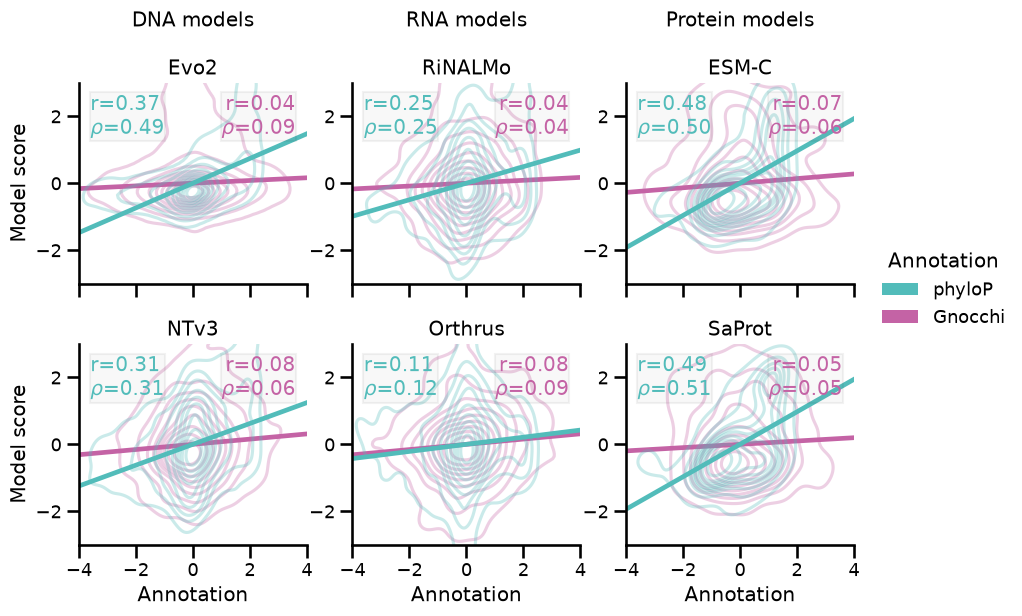

In [186]:
with sns.plotting_context("talk", font_scale=0.8):
    all_corrs = model_annotation_correlation_plot(
        df,
        use_z_scores=True,
    )
    save_fig("fig3_scores_vs_annots.pdf")


0.08569759313485105
0.08569759313485105
0.36005102433277997
0.36005102433277997
0.3681788346420926
0.3681788346420926
0.413042137812205
0.413042137812205
0.15798313781221524
0.15798313781221524
0.1546653986907567
0.1546653986907567


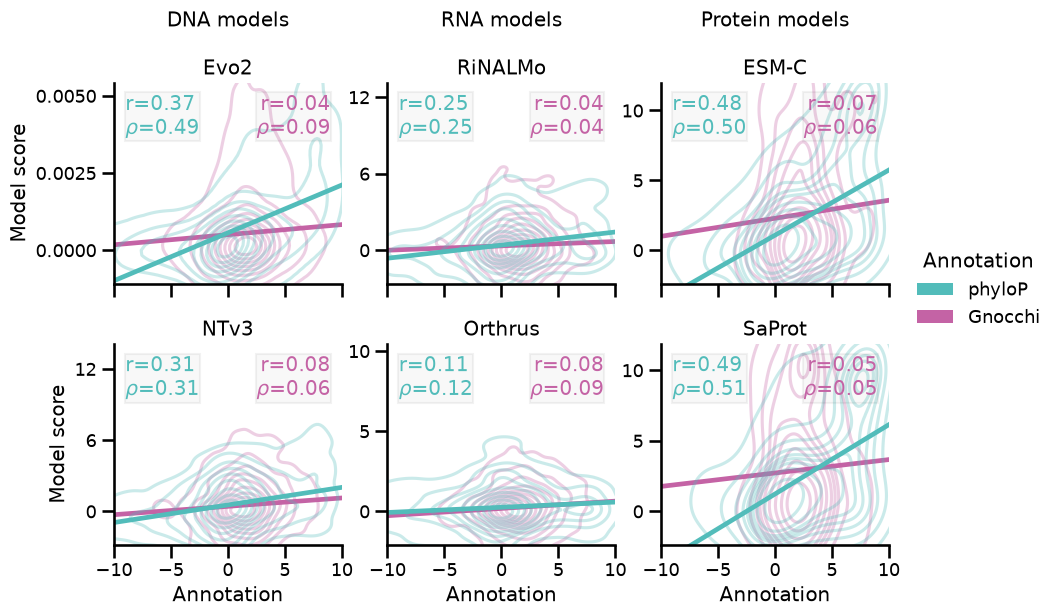

In [190]:
with sns.plotting_context("talk", font_scale=0.8):
    all_corrs = model_annotation_correlation_plot(
        df,
    )
    save_fig("app_fig_scores_vs_annots.raw_values.pdf")


### Old corr plots

In [ ]:
hist_color = "#3C6E71"
fit_color = "#D1495B"


def corr_model_vs_annotations(
    data: pl.DataFrame,
    model_col: str,
    annotations: dict[str, str] = annot_names,
    model_name: str | None = None,
    clip: bool = True,
) -> pl.dataframe:
    if model_name is None:
        model_name = model_col

    fig, axs = plt.subplots(
        nrows=1,
        ncols=len(annotations),
        sharex=False,
        figsize=(10, 4),
    )
    sns.despine(fig)

    if clip:
        scores = data.get_column(model_col).drop_nulls().to_numpy()
        ymin, ymax = np.quantile(scores, q=(0.001, 0.999))

    corr_data = []
    for i, ((annot, name), ax) in enumerate(zip(annotations.items(), axs)):
        plot_data = data.filter(
            pl.col(model_col).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        x_vals = plot_data.get_column(annot).to_numpy()
        y_vals = plot_data.get_column(model_col).to_numpy()
        r = pearsonr(x_vals, y_vals)
        rho = spearmanrho(x_vals, y_vals)

        sns.regplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            marker=".",
            line_kws={"color": fit_color, "alpha": 0.7},
            ax=ax,
            scatter=False,
        )
        sns.histplot(
            x=plot_data.get_column(annot),
            y=plot_data.get_column(model_col),
            alpha=1,
            color=hist_color,
            ax=ax,
        )
        ax.set_xlabel(name)
        ax.text(
            0.95,
            0.95,
            s=(
                f"r={r.statistic:0.2f}"
                "\n"
                rf"$\rho$={rho.statistic:0.2f}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
        )
        if i == 0:
            ax.set_ylabel(model_name)
        else:
            ax.set_ylabel(None)
        if clip:
            ax.set_ylim(ymin, ymax)
        corr_data.append(
            {
                "model_name": model_name,
                "name": name,
                "pearson": r.statistic,
                "spearman": rho.statistic,
            }
        )

    plt.tight_layout()
    return pl.DataFrame(corr_data)

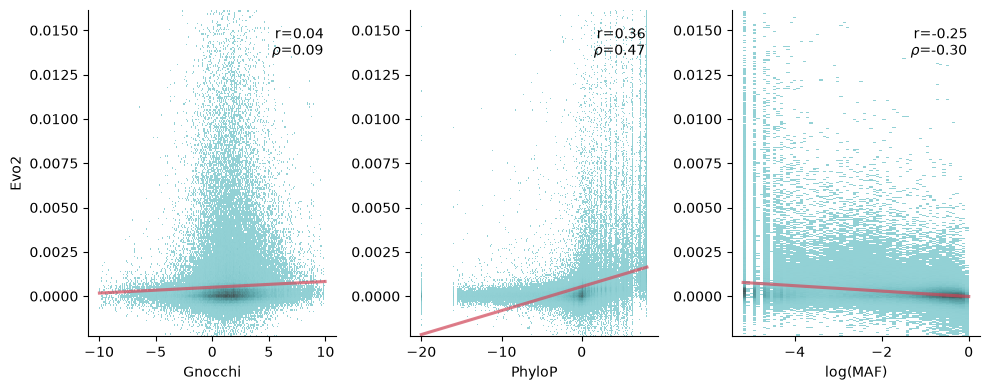

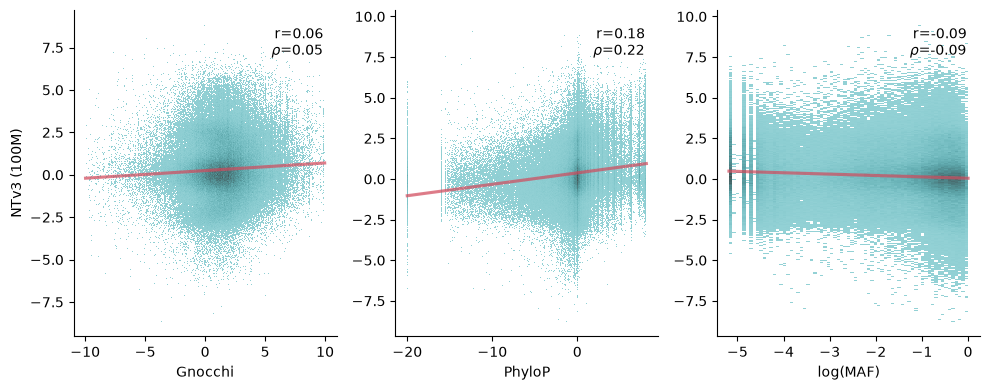

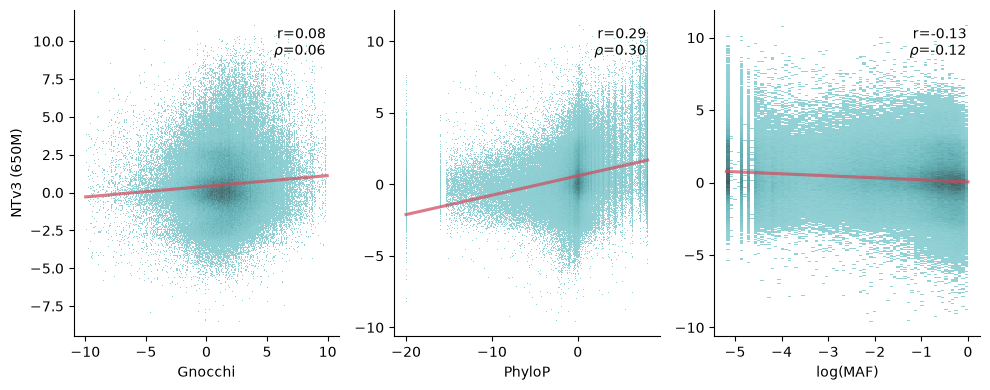

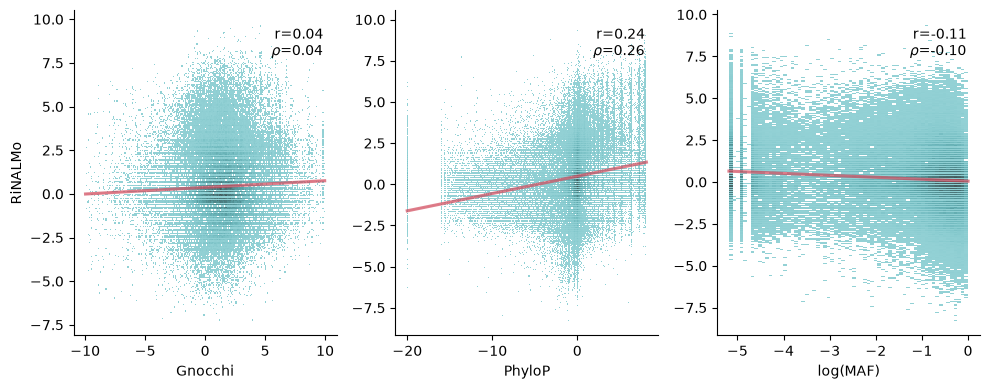

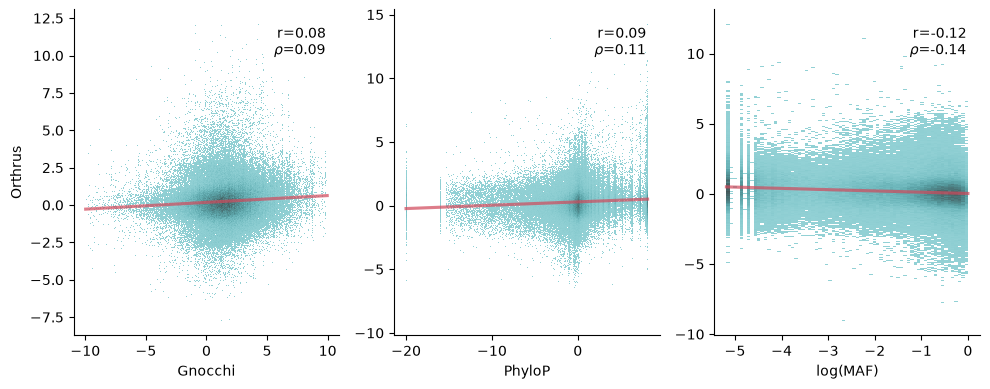

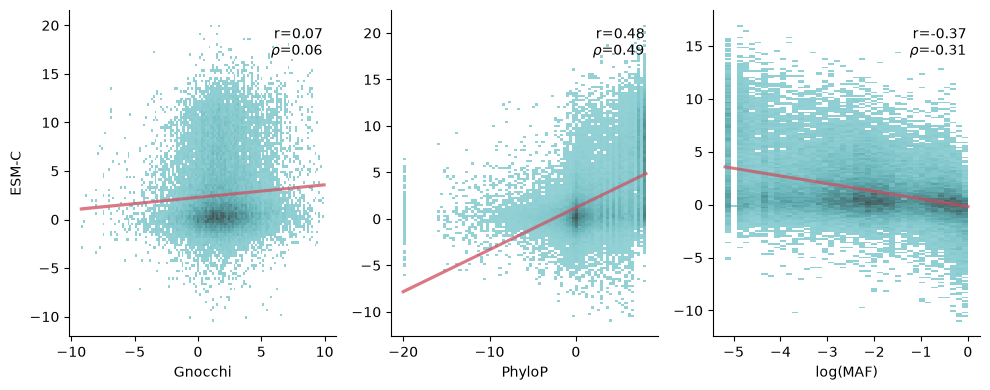

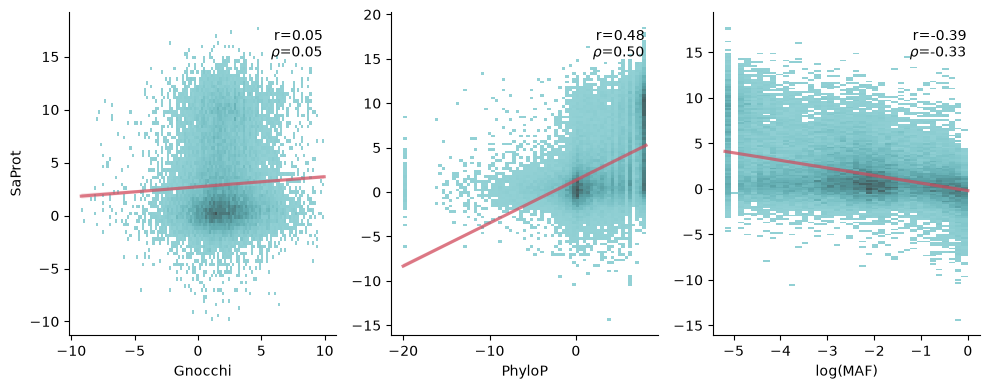

In [15]:
want_annots = {k: v for k, v in annot_names.items() if "roulette" not in k}

all_corrs = []
for score_name, pretty_name in model_names.items():
    all_corrs.append(
        corr_model_vs_annotations(
            data=df,
            model_col=score_name,
            model_name=pretty_name,
            clip=score_name == "evo_score",
            annotations=want_annots,
        )
    )
    plt.show()

all_corrs = pl.concat(all_corrs)

In [16]:
(
    all_corrs.filter(pl.col("model_name") != "NTv3 (100M)")
    .group_by("name")
    .agg(
        pearson=pl.col("pearson").median(),
        spearman=pl.col("spearman").median(),
    )
)

name,pearson,spearman
str,f64,f64
"""log(MAF)""",-0.191074,-0.222937
"""PhyloP""",0.32302,0.386258
"""Gnocchi""",0.059161,0.061649


# Appendix Figure 1: phyloP vs Gnocchi

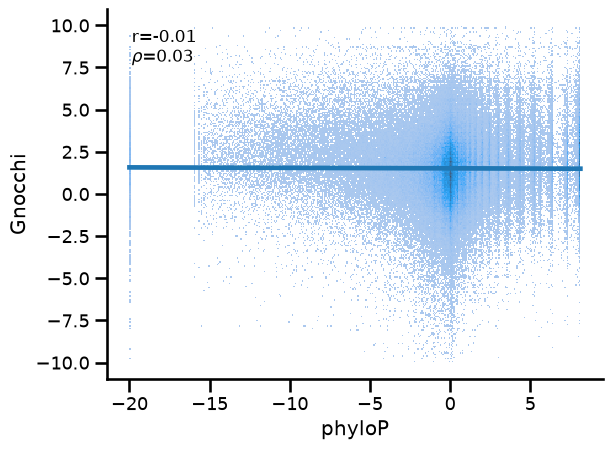

In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    want_annots = ["phylop", "gnocchi_z"]
    plot_data = df.filter(pl.all_horizontal(pl.col(want_annots).is_not_null())).select(
        want_annots
    )

    ax = sns.histplot(x="phylop", y="gnocchi_z", data=plot_data)

    sns.regplot(
        x="phylop",
        y="gnocchi_z",
        scatter=False,
        ax=ax,
        data=plot_data,
    )

    xvals = plot_data.get_column("phylop").to_numpy()
    yvals = plot_data.get_column("gnocchi_z").to_numpy()

    r = pearsonr(xvals, yvals)
    rho = spearmanrho(xvals, yvals)
    ax.text(
        0.05,
        0.95,
        s=(
            f"r={r.statistic:0.2f}"
            "\n"
            rf"$\rho$={rho.statistic:0.2f}"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        size="small",
    )
    ax.set_xlabel("phyloP")
    ax.set_ylabel("Gnocchi")
    sns.despine(ax=ax)

    save_fig("app_fig1_phylop_vs_gnocchi.pdf")

# Table 2: Model classification of binned annotations

In [48]:
flip = ["gnomadg_af_log"]
results = []
for model, model_name in score_to_model.items():
    for annot, annot_name in annot_names.items():
        want_data = df.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""phyloP""",0.838214,0.866503,78848,78830
"""Evo2""","""Gnocchi""",0.573088,0.555961,53941,53942
"""Evo2""","""log(MAF)""",0.709823,0.728732,66010,66004
"""NTv3 (100M)""","""phyloP""",0.658854,0.653588,82407,82391
"""NTv3 (100M)""","""Gnocchi""",0.539454,0.530529,56393,56394
"""NTv3 (100M)""","""log(MAF)""",0.563736,0.553314,69331,69328
"""NTv3""","""phyloP""",0.718373,0.733728,82407,82391
"""NTv3""","""Gnocchi""",0.549371,0.551978,56393,56394
…,…,…,…,…,…


In [49]:
(
    results.filter(
        pl.col("model") != "NTv3 (100M)",
        pl.col("annotation") != "log(MAF)",
    )
    .with_columns(modality=pl.col("model").replace(model_to_modality))
    .select("modality", "model", "annotation", "auroc")
)

modality,model,annotation,auroc
str,str,str,f64
"""DNA""","""Evo2""","""phyloP""",0.838214
"""DNA""","""Evo2""","""Gnocchi""",0.573088
"""DNA""","""NTv3""","""phyloP""",0.718373
"""DNA""","""NTv3""","""Gnocchi""",0.549371
"""RNA""","""RiNALMo""","""phyloP""",0.677725
"""RNA""","""RiNALMo""","""Gnocchi""",0.533014
"""RNA""","""Orthrus""","""phyloP""",0.577727
"""RNA""","""Orthrus""","""Gnocchi""",0.566287
"""Protein""","""ESM-C""","""phyloP""",0.862592


In [73]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""Gnocchi""",0.546667,0.549761
"""phyloP""",0.778294,0.800116
"""log(MAF)""",0.658735,0.659166


In [50]:
# Shared sites only
results = []

shared_data = df.filter(pl.all_horizontal(pl.col(*score_to_model.keys())).is_not_null())

for model, model_name in score_to_model.items():
    for annot, annot_name in annot_names.items():
        want_data = shared_data.filter(
            pl.col(model).is_not_null(),
            pl.col(annot).is_not_null(),
        )
        low_thresh, high_thresh = want_data.get_column(annot).quantile([0.25, 0.75])

        high_label = 0 if annot in flip else 1
        low_label = 1 if annot in flip else 0

        labeled_data = want_data.with_columns(
            label=(
                pl.when(pl.col(annot) <= low_thresh)
                .then(low_label)
                .otherwise(
                    pl.when(pl.col(annot) >= high_thresh)
                    .then(high_label)
                    .otherwise(None)
                )
            )
        ).filter(pl.col("label").is_not_null())
        y_true = labeled_data.get_column("label")
        y_score = labeled_data.get_column(model)
        results.append(
            {
                "model": model_name,
                "annotation": annot_name,
                "auroc": roc_auc_score(y_true=y_true, y_score=y_score),
                "auprc": average_precision_score(y_true=y_true, y_score=y_score),
                "num_pos": y_true.sum(),
                "num_neg": len(y_true) - y_true.sum(),
            }
        )
results = pl.DataFrame(results)
results

model,annotation,auroc,auprc,num_pos,num_neg
str,str,f64,f64,i64,i64
"""Evo2""","""phyloP""",0.953304,0.944646,11423,11419
"""Evo2""","""Gnocchi""",0.575056,0.537565,8039,8040
"""Evo2""","""log(MAF)""",0.806512,0.796992,9469,9469
"""NTv3 (100M)""","""phyloP""",0.564788,0.585641,11536,11541
"""NTv3 (100M)""","""Gnocchi""",0.519035,0.529645,8128,8128
"""NTv3 (100M)""","""log(MAF)""",0.48375,0.504566,9584,9581
"""NTv3""","""phyloP""",0.756263,0.800954,11536,11541
"""NTv3""","""Gnocchi""",0.567671,0.582704,8128,8128
…,…,…,…,…,…


In [51]:
(
    results.filter(pl.col("model") != "NTv3 (100M)")
    .group_by("annotation")
    .agg(
        auroc=pl.col("auroc").median(),
        auprc=pl.col("auprc").median(),
    )
)

annotation,auroc,auprc
str,f64,f64
"""Gnocchi""",0.536259,0.53933
"""log(MAF)""",0.664832,0.698717
"""phyloP""",0.810202,0.840449


# Figure 2: MAF and phyloP by dataset

In [19]:
def melt_scores(df: pl.DataFrame, name: str) -> pl.DataFrame:
    return (
        df.unpivot(
            on=["phylop", "gnomadg_af_log", "gnocchi_z"],
            index="variant",
        )
        .with_columns(dataset=pl.lit(name))
        .filter(pl.col("value").is_not_null())
    )


plot_data = pl.concat(
    (
        melt_scores(
            df.filter(
                pl.col("gwas_label").is_not_null(), pl.col("gwas_label") == "high_pip"
            ),
            "GWAS",
        ),
        melt_scores(
            df.filter(
                pl.col("eqtl_label").is_not_null(), pl.col("eqtl_label") == "high_pip"
            ),
            "eQTL",
        ),
        melt_scores(
            df.filter(
                pl.col("clinvar_label").is_not_null(),
                pl.col("clinvar_label").str.contains("athogenic"),
            ),
            "ClinVar",
        ),
    )
)
plot_data.head()

variant,variable,value,dataset
str,str,f64,str
"""chr1:1204482:T:C""","""phylop""",-3.715,"""GWAS"""
"""chr1:2512975:G:A""","""phylop""",2.808,"""GWAS"""
"""chr1:3473193:A:G""","""phylop""",6.807,"""GWAS"""
"""chr1:3774964:A:G""","""phylop""",-0.515,"""GWAS"""
"""chr1:6236178:T:G""","""phylop""",-2.971,"""GWAS"""


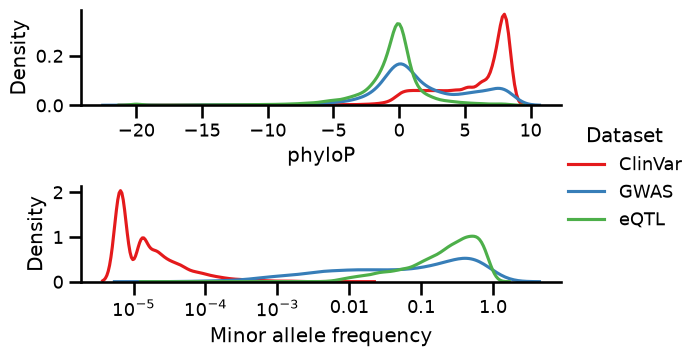

In [20]:
def maf_format(x, pos):
    if x < -2:
        return rf"$10^{{{int(x)}}}$"
    return f"{10**x}"


with sns.plotting_context("talk", font_scale=0.8):
    fg = sns.FacetGrid(
        aspect=3,
        height=2,
        row="variable",
        hue="dataset",
        hue_order=["ClinVar", "GWAS", "eQTL"],
        sharex=False,
        sharey=False,
        palette="Set1",
        data=(
            plot_data.filter(
                pl.col("variable").is_in(["phylop", "gnomadg_af_log"])
            ).with_columns(
                variable=pl.col("variable").replace(
                    {"phylop": "phyloP", "gnomadg_af_log": "MAF"}
                )
            )
        ),
    )
    fg.map_dataframe(
        sns.kdeplot,
        x="value",
        common_norm=False,
        legend=True,
    )
    for name, ax in fg.axes_dict.items():
        ax.set_xlabel(name)
        ax.set_title("")

        if name == "MAF":
            # locs, labels = ax.get_xticks()
            ax.xaxis.set_major_formatter(ticker.FuncFormatter(maf_format))
            ax.set_xlabel("Minor allele frequency")

    fg.add_legend(title="Dataset")
    save_fig("fig2_phylop_maf_by_dataset.pdf")

# Univariate dataset performance

In [61]:
def raw_score_comparison_simple(
    data: pl.DataFrame,
    dataset_labels: dict[str, list[str]] = dataset_labels,
    scores: list[str] = list(annot_names.keys()) + list(score_to_model.keys()),
    title: str | None = None,
) -> pl.DataFrame:

    want_data = data.with_columns(
        **{
            f"{dataset}": pl.col(f"{dataset}_label").is_in(pos_labels).cast(pl.UInt8)
            for dataset, pos_labels in dataset_labels.items()
        }
    ).filter(pl.all_horizontal(pl.col(*scores).is_not_null()))

    metrics = []
    for dataset in dataset_labels:
        ds_data = want_data.filter(pl.col(dataset).is_not_null())
        y_true = ds_data.get_column(dataset)
        print(f"{dataset}: {y_true.sum()} / {len(y_true)}")

        for score in scores:
            y_pred = ds_data.get_column(score)
            metrics.append(
                {
                    "dataset": dataset,
                    "score": score,
                    "auroc": roc_auc_score(y_true=y_true, y_score=y_pred),
                    "auprc": average_precision_score(y_true=y_true, y_score=y_pred),
                }
            )

    score_rename = {}
    score_rename.update(annot_names)
    score_rename.update(score_to_model)
    metrics = pl.DataFrame(metrics).with_columns(
        score=pl.col("score").replace(score_rename),
        dataset=pl.col("dataset").replace(dataset_names),
    )
    ax = sns.barplot(
        x="dataset",
        hue="score",
        y="auroc",
        legend=True,
        data=metrics,
    )
    plt.legend(title="Model")

    ax.set_ylim(0.4)
    ax.axhline(y=0.5, linestyle="--", alpha=0.6, color="black")
    ax.set_ylabel("AUROC")
    sns.despine()

    if title is not None:
        plt.title(title)
    plt.tight_layout()

    return metrics

gwas: 426 / 6664
eqtl: 345 / 2530
clinvar: 6316 / 19549


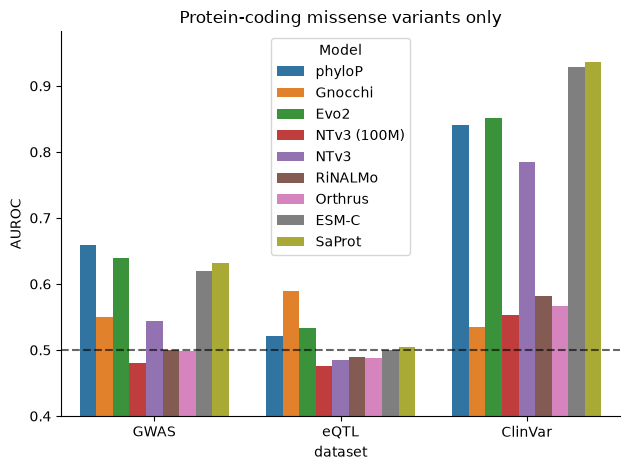

In [74]:
want_scores = [
    x
    for x in list(annot_names.keys()) + list(score_to_model.keys())
    if x
    not in [
        "gnomadg_af_log",
    ]
]
ms_scores = raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=want_scores,
)


gwas: 628 / 9819
eqtl: 613 / 3893
clinvar: 8829 / 27372


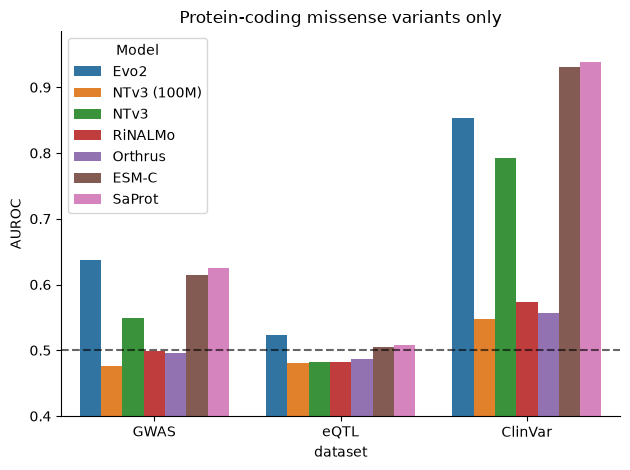

In [ ]:
_ = raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=list(score_to_model.keys()),
)


In [76]:
df.select(**{name: pl.col(name).is_not_null().sum() for name in score_to_model})

evo_score,nt_100_score,nt_650_score,rinalmo_score,orthrus_score,esmc_score,saprot_score
u32,u32,u32,u32,u32,u32,u32
315327,329585,329585,329585,329585,48149,38017


gwas: 628 / 9844
eqtl: 620 / 3938
clinvar: 8901 / 27778


dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.614645,0.113899
"""GWAS""","""SaProt""",0.625879,0.110628
"""eQTL""","""ESM-C""",0.505598,0.170813
"""eQTL""","""SaProt""",0.508113,0.172092
"""ClinVar""","""ESM-C""",0.930681,0.894633
"""ClinVar""","""SaProt""",0.938272,0.898905


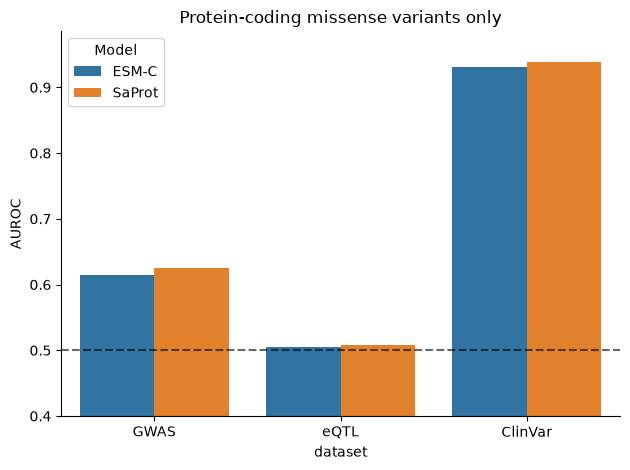

In [77]:
raw_score_comparison_simple(
    df,
    title="Protein-coding missense variants only",
    scores=["esmc_score", "saprot_score"],
)


gwas: 1137 / 81284
eqtl: 6261 / 49162
clinvar: 17194 / 109170


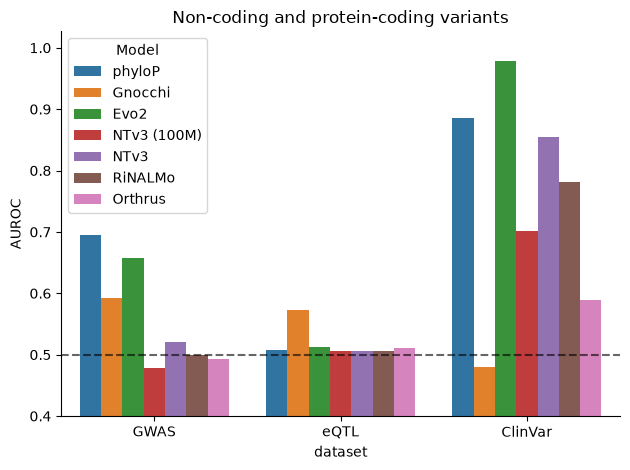

In [78]:
gw_scores = raw_score_comparison_simple(
    df,
    scores=[x for x in want_scores if x not in ["esmc_score", "saprot_score"]],
    title="Non-coding and protein-coding variants",
)

In [86]:
combined_scores = pl.concat(
    (
        ms_scores.filter(pl.col("score").is_in(["ESM-C", "SaProt"])),
        gw_scores.filter(pl.col("score") != "NTv3 (100M)"),
    )
)
combined_scores.head()

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.619357,0.112913
"""GWAS""","""SaProt""",0.631676,0.111306
"""eQTL""","""ESM-C""",0.500316,0.144505
"""eQTL""","""SaProt""",0.504293,0.147357
"""ClinVar""","""ESM-C""",0.929008,0.894282


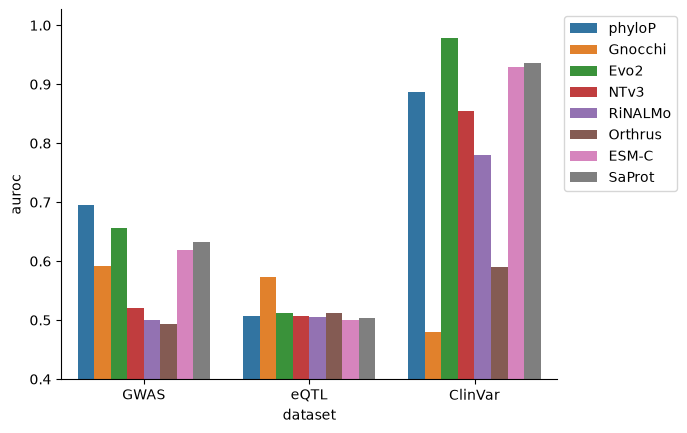

In [87]:
hue_order = [
    x
    for x in list(annot_names.values()) + list(score_to_model.values())
    if x not in ["NTv3 (100M)", "log(MAF)"]
]
sns.barplot(
    x="dataset",
    y="auroc",
    hue="score",
    hue_order=hue_order,
    data=combined_scores.filter(),
)
plt.ylim(0.4)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()

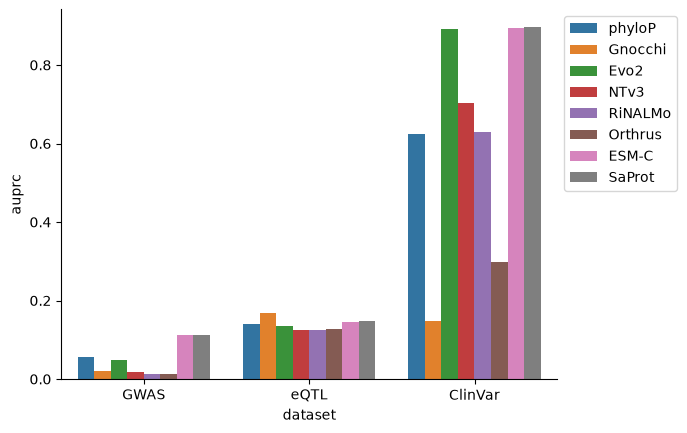

In [88]:
hue_order = [
    x
    for x in list(annot_names.values()) + list(score_to_model.values())
    if x not in ["NTv3 (100M)", "log(MAF)"]
]
sns.barplot(
    x="dataset",
    y="auprc",
    hue="score",
    hue_order=hue_order,
    data=combined_scores,
)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()

In [89]:
combined_scores.sort("dataset", "score").filter(pl.col("dataset") != "ClinVar")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""ESM-C""",0.619357,0.112913
"""GWAS""","""Evo2""",0.656844,0.049309
"""GWAS""","""Gnocchi""",0.592237,0.020991
"""GWAS""","""NTv3""",0.521229,0.017485
"""GWAS""","""Orthrus""",0.493586,0.013524
"""GWAS""","""RiNALMo""",0.500091,0.014046
"""GWAS""","""SaProt""",0.631676,0.111306
"""GWAS""","""phyloP""",0.694581,0.055734
…,…,…,…


In [90]:
combined_scores.filter(pl.col("score") == "SaProt")

dataset,score,auroc,auprc
str,str,f64,f64
"""GWAS""","""SaProt""",0.631676,0.111306
"""eQTL""","""SaProt""",0.504293,0.147357
"""ClinVar""","""SaProt""",0.93581,0.896677


In [91]:
(
    combined_scores.with_columns(
        modality=pl.col("score").replace(model_to_modality)
    ).write_csv("./tmp_scores.csv")
)

In [84]:
(
    ms_scores.with_columns(
        modality=pl.col("score").replace(model_to_modality)
    ).write_csv("./ms_tmp_scores.csv")
)

In [92]:
combined_scores.group_by("dataset").agg(pl.median("auroc"), pl.median("auprc"))

dataset,auroc,auprc
str,f64,f64
"""GWAS""",0.605797,0.03515
"""ClinVar""",0.870515,0.665115
"""eQTL""",0.507012,0.137606


# Complementarity

In [21]:
def prepare_labeled_data(
    data: pl.DataFrame,
    feature_cols: list[str],
    label_columns: list[str],
) -> pl.DataFrame:
    """Collapse labels to single binary 0/1 labels."""
    return data.filter(
        pl.all_horizontal(pl.col(feature_cols).is_not_null()),
        pl.any_horizontal(pl.col(label_columns).is_not_null()),
    ).with_columns(
        label=pl.any_horizontal(
            (pl.col(label_columns) == "high_pip").fill_null(False),
            (pl.col(label_columns).str.contains("athogenic")).fill_null(False),
        ).cast(pl.Int8),
    )


def select_biotype_group(
    data: pl.DataFrame,
    biotype: Literal["all", "protein_coding", "lncRNA"],
) -> pl.DataFrame:
    return data if biotype == "all" else data.filter(pl.col("biotype") == biotype)


def cv_eval_models(
    full_data: pl.DataFrame,
    label_cols: list[str],
    models: dict[str, Any],
    cv: StratifiedGroupKFold,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, np.ndarray, dict[str, np.ndarray]]:
    if shared_variants_only:
        all_features = list(
            {feat_name for features, _ in models.values() for feat_name in features}
        )
        full_data = prepare_labeled_data(
            data=full_data,
            feature_cols=all_features,
            label_columns=label_cols,
        )

    predictions = {}
    metrics = []
    for model_name, (features, model) in models.items():
        labeled_data = prepare_labeled_data(
            data=full_data,
            feature_cols=features,
            label_columns=label_cols,
        )

        groups = labeled_data.get_column("variant").to_numpy()
        y = labeled_data.get_column("label").to_numpy()

        prediction = cross_val_predict(
            model,
            labeled_data.select(features).to_numpy(),
            y,
            groups=groups,
            cv=cv,
            method="predict_proba",
            n_jobs=2,
        )[:, 1]
        predictions[model_name] = prediction
        metrics.append(
            {
                "model": model_name,
                "auroc": roc_auc_score(y, prediction),
                "auprc": average_precision_score(y, prediction),
            }
        )
    return pl.DataFrame(metrics), y, predictions


def eval_all_datasets(
    full_data: pl.DataFrame,
    dataset_specs: dict[str, list[str]],
    want_biotypes: list[str],
    model_specs: dict[str, Any],
    n_folds: int = 5,
    shared_variants_only: bool = False,
) -> tuple[pl.DataFrame, dict[str, np.ndarray], dict[str, np.ndarray]]:
    complementarity_cv = StratifiedGroupKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42,
    )

    oof_predictions = {}
    oof_outcomes = {}
    model_metrics = []
    for dataset, label_columns in dataset_specs.items():
        for biotype in want_biotypes:
            data = select_biotype_group(full_data, biotype)
            metrics, _y, _predictions = cv_eval_models(
                full_data=data,
                label_cols=label_columns,
                models=model_specs,
                cv=complementarity_cv,
                shared_variants_only=shared_variants_only,
            )
            key = (dataset, biotype)
            oof_outcomes[key] = _y
            oof_predictions[key] = _predictions
            model_metrics.append(
                metrics.with_columns(dataset=pl.lit(dataset), biotype=pl.lit(biotype))
            )
    model_metrics = pl.concat(model_metrics).sort(
        "dataset", "biotype", "auroc", descending=[False, False, True]
    )
    return model_metrics, oof_predictions, oof_outcomes


In [22]:
dataset_specs = {
    "GWAS": ["ukbb_label", "multisusie_label"],
    "eQTL": ["eqtl_label"],
    "All": ["ukbb_label", "multisusie_label", "eqtl_label"],
    "ClinVar": ["clinvar_label"],
}
analysis_biotypes = ["all", "protein_coding", "lncRNA"]

group_sizes = pl.DataFrame(
    [
        {
            "dataset": _dataset,
            "biotype": _biotype,
            "variants": len(_data),
            "high_pip": _data.get_column("label").sum(),
            "low_pip": len(_data) - _data.get_column("label").sum(),
        }
        for _dataset, _label_columns in dataset_specs.items()
        for _biotype in analysis_biotypes
        for _data in [
            select_biotype_group(
                prepare_labeled_data(df, ["phylop", "gnocchi_z"], _label_columns),
                _biotype,
            )
        ]
    ]
)
group_sizes

dataset,biotype,variants,high_pip,low_pip
str,str,i64,i64,i64
"""GWAS""","""all""",81631,1138,80493
"""GWAS""","""protein_coding""",53510,910,52600
"""GWAS""","""lncRNA""",28121,228,27893
"""eQTL""","""all""",49988,6440,43548
"""eQTL""","""protein_coding""",34597,3864,30733
"""eQTL""","""lncRNA""",15391,2576,12815
"""All""","""all""",114952,7486,107466
"""All""","""protein_coding""",75528,4701,70827
"""All""","""lncRNA""",39424,2785,36639


In [23]:
lr_cv_params = {
    "l1_ratios": (0.0,),
    "scoring": "neg_log_loss",
    "use_legacy_attributes": False,
    "n_jobs": 8,
}

linear_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)

interaction_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegressionCV(**lr_cv_params),
)


def model_to_specs(score_name: str) -> dict[str, Any]:
    shorthand = score_name.replace("_score", "")
    return {
        f"{shorthand}_gnocchi": (
            [score_name, "gnocchi_z"],
            interaction_model,
        ),
        f"{shorthand}_phylop": ([score_name, "phylop"], interaction_model),
        f"{shorthand}_gnocchi_phylop": (
            [score_name, "gnocchi_z", "phylop"],
            interaction_model,
        ),
    }


model_specs = {
    "PhyloP": (["phylop"], linear_model),
    "Gnocchi": (["gnocchi_z"], linear_model),
}

for score_name, pretty_name in score_to_model.items():
    model_specs.update({pretty_name: ([score_name], linear_model)})
    model_specs.update(model_to_specs(score_name))

In [24]:
regen = False

In [25]:
# Missense variants only, due to inclusion of ESM-C as a model
if regen:
    ms_perf_metrics, ms_all_preds, ms_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=model_specs,
        shared_variants_only=True,
    )

    with open(
        project_dir / "classification" / "missense_preds.pkl",
        "wb",
    ) as fh:
        dump((ms_perf_metrics, ms_all_preds, ms_all_labels), fh)

else:
    with open(
        project_dir / "classification" / "missense_preds.pkl",
        "rb",
    ) as fh:
        ms_perf_metrics, ms_all_preds, ms_all_labels = load(fh)

ms_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""esmc_gnocchi_phylop""",0.586035,0.128567,"""All""","""all"""
"""saprot_gnocchi_phylop""",0.581942,0.12474,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.578275,0.12042,"""All""","""all"""
"""nt_100_gnocchi_phylop""",0.576845,0.117269,"""All""","""all"""
"""esmc_gnocchi""",0.576795,0.122673,"""All""","""all"""


In [26]:
# All variants, excluding ESM-C and SaProt as a model
if regen:
    gw_specs = {}
    for name, spec in model_specs.items():
        if "esm" in name.lower() or "saprot" in name.lower():
            continue
        gw_specs[name] = spec

    gw_perf_metrics, gw_all_preds, gw_all_labels = eval_all_datasets(
        full_data=df,
        dataset_specs=dataset_specs,
        want_biotypes=["all"],
        model_specs=gw_specs,
        shared_variants_only=True,
    )
    with open(
        project_dir / "classification" / "genome_wide_preds.pkl",
        "wb",
    ) as fh:
        dump((gw_perf_metrics, gw_all_preds, gw_all_labels), fh)

else:
    with open(
        project_dir / "classification" / "genome_wide_preds.pkl",
        "rb",
    ) as fh:
        gw_perf_metrics, gw_all_preds, gw_all_labels = load(fh)

gw_perf_metrics.head()

model,auroc,auprc,dataset,biotype
str,f64,f64,str,str
"""orthrus_gnocchi_phylop""",0.573665,0.084434,"""All""","""all"""
"""nt_100_gnocchi_phylop""",0.572422,0.084298,"""All""","""all"""
"""rinalmo_gnocchi_phylop""",0.570292,0.083937,"""All""","""all"""
"""nt_650_gnocchi_phylop""",0.568984,0.083651,"""All""","""all"""
"""orthrus_gnocchi""",0.567082,0.080346,"""All""","""all"""


In [27]:
def sample_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC and AUPRC"""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_true_sample, y_pred_sample = resample(y_true, y_pred, random_state=rng)
        results["auroc"].append(
            roc_auc_score(y_true=y_true_sample, y_score=y_pred_sample)
        )
        results["auprc"].append(
            average_precision_score(y_true=y_true_sample, y_score=y_pred_sample)
        )

    return results


def sample_metric_deltas(
    y_pred_ref: np.ndarray,
    y_pred_oth: np.ndarray,
    y_true: np.ndarray,
    job_idx: int,
    num_bootstraps: int = 100,
) -> dict[str, list[float]]:
    """Bootstrapped estimates of AUROC delta between two models."""
    rng = np.random.RandomState(seed=42 + job_idx)

    results = defaultdict(list)
    for i in range(num_bootstraps):
        y_ref, y_oth, y_t = resample(y_pred_ref, y_pred_oth, y_true, random_state=rng)

        auroc_ref = roc_auc_score(y_t, y_ref)
        auroc_oth = roc_auc_score(y_t, y_oth)
        results["auroc"].append(auroc_oth - auroc_ref)
        results["auroc_pct"].append(100 * (auroc_oth - auroc_ref) / auroc_ref)

        auprc_ref = average_precision_score(y_t, y_ref)
        auprc_oth = average_precision_score(y_t, y_oth)
        results["auprc"].append(auprc_oth - auprc_ref)
        results["auprc_pct"].append(100 * (auprc_oth - auprc_ref) / auprc_ref)
    return results


def nested_metrics_to_df(
    x: list[dict[str, list[str]]],
    index_items: dict[str, str],
) -> pl.DataFrame:
    flat = defaultdict(list)
    for d in x:
        for k, l in d.items():
            flat[k].extend(l)

    flat.update(index_items)
    return pl.DataFrame(flat)


def run_bootstrap_estimates(
    preds: dict[tuple[str, str], dict[str, np.ndarray]],
    labels: dict[tuple[str, str], np.ndarray],
    comparisons=list[tuple[str, tuple[str]]],
    n_jobs: int = 8,
    num_bootstraps_per_job: int = 100,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    seen = set()
    bootstrapped_metrics = []
    bootstrapped_diffs = []

    with Pool(processes=n_jobs) as p:
        for (dataset, biotype), y_true in labels.items():
            for ref_model, compare_models in comparisons:
                y_ref = preds[(dataset, biotype)][ref_model]

                metric_func = partial(sample_metrics, y_true, y_ref)
                bootstrapped_metrics.append(
                    nested_metrics_to_df(
                        x=p.map(metric_func, range(n_jobs)),
                        index_items={"model": ref_model, "dataset": dataset},
                    )
                )

                for compare_model in compare_models:
                    y_oth = preds[(dataset, biotype)][compare_model]

                    if (compare_model, dataset) not in seen:
                        metric_func = partial(sample_metrics, y_true, y_oth)
                        bootstrapped_metrics.append(
                            nested_metrics_to_df(
                                x=p.map(metric_func, range(n_jobs)),
                                index_items={
                                    "model": compare_model,
                                    "dataset": dataset,
                                },
                            )
                        )
                        seen.add((compare_model, dataset))

                    metric_func = partial(sample_metric_deltas, y_ref, y_oth, y_true)
                    bootstrapped_diffs.append(
                        nested_metrics_to_df(
                            x=p.map(metric_func, range(n_jobs)),
                            index_items={
                                "ref": ref_model,
                                "compare": compare_model,
                                "dataset": dataset,
                            },
                        )
                    )
    return pl.concat(bootstrapped_metrics), pl.concat(bootstrapped_diffs)

In [28]:
def make_comparison_lists(
    want_references: list[str],
) -> list[tuple]:
    ret = []
    pretty_to_score = {v: k for k, v in score_to_model.items()}

    for ref in want_references:
        shorthand = pretty_to_score[ref].replace("_score", "")
        ret.append(
            (
                ref,
                (
                    f"{shorthand}_phylop",
                    f"{shorthand}_gnocchi",
                    f"{shorthand}_gnocchi_phylop",
                ),
            )
        )
    return ret


ms_delta_comparisons = make_comparison_lists(
    want_references=list(score_to_model.values())
)
gw_delta_comparisons = make_comparison_lists(
    want_references=[
        x for x in score_to_model.values() if x not in ["ESM-C", "SaProt"]
    ],
)

In [29]:
if regen:
    ms_bootstrap_metrics, ms_bootstrap_diffs = run_bootstrap_estimates(
        preds=ms_all_preds,
        labels=ms_all_labels,
        comparisons=ms_delta_comparisons,
    )
    with open(
        project_dir / "classification" / "missense_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((ms_bootstrap_metrics, ms_bootstrap_diffs), fh)

else:
    with open(
        project_dir / "classification" / "missense_bootstraps.pkl",
        "rb",
    ) as fh:
        ms_bootstrap_metrics, ms_bootstrap_diffs = load(fh)

ms_bootstrap_metrics.head()

auroc,auprc,model,dataset
f64,f64,str,str
0.642062,0.102433,"""Evo2""","""GWAS"""
0.629201,0.097294,"""Evo2""","""GWAS"""
0.644784,0.119159,"""Evo2""","""GWAS"""
0.652068,0.113874,"""Evo2""","""GWAS"""
0.659678,0.123283,"""Evo2""","""GWAS"""


In [30]:
if regen:
    gw_bootstrap_metrics, gw_bootstrap_diffs = run_bootstrap_estimates(
        preds=gw_all_preds,
        labels=gw_all_labels,
        comparisons=gw_delta_comparisons,
    )
    with open(
        project_dir / "classification" / "genome_wide_bootstraps.pkl",
        "wb",
    ) as fh:
        dump((gw_bootstrap_metrics, gw_bootstrap_diffs), fh)

else:
    with open(
        project_dir / "classification" / "genome_wide_bootstraps.pkl",
        "rb",
    ) as fh:
        gw_bootstrap_metrics, gw_bootstrap_diffs = load(fh)

gw_bootstrap_metrics.head()

auroc,auprc,model,dataset
f64,f64,str,str
0.656121,0.051701,"""Evo2""","""GWAS"""
0.673406,0.059053,"""Evo2""","""GWAS"""
0.651147,0.044317,"""Evo2""","""GWAS"""
0.666065,0.051747,"""Evo2""","""GWAS"""
0.645559,0.058483,"""Evo2""","""GWAS"""


In [31]:
def feature_list_to_sort_key(
    features: list[str],
    feature_order: list[str],
) -> int:
    return sum([2 ** feature_order.index(x) for x in features])


def plot_feature_comparison(
    data: pl.DataFrame,
    ax: plt.Axes,
    ax_sets: plt.Axes,
    feature_order: list[str],
    title: str | None = None,
    modality: str | None = None,
    twiny_ax: plt.Axes | None = None,
):
    """Plot performance bars and corresponding UpSet-style feature matrix."""
    # Restrict to comparisons where all features are in the desired feature set
    specs_to_features = {k: v[0] for k, v in model_specs.items()}
    data = (
        data.with_columns(
            feature_set=pl.col("compare").replace_strict(
                specs_to_features, return_dtype=pl.List
            ),
        )
        .filter(
            pl.col("feature_set").list.set_difference(feature_order).list.len() == 0,
        )
        .drop("feature_set")
    )

    names_and_features = sorted(
        [(name, model_specs[name][0]) for name in data.get_column("compare").unique()],
        key=lambda x: feature_list_to_sort_key(x[1], feature_order),
    )
    names, feature_sets = zip(*names_and_features)
    common_kwargs = {
        "x": "compare",
        "order": names,
        "estimator": np.mean,
        "errorbar": ("pi", 95),
        "data": data,
    }
    if modality is not None:
        common_kwargs["facecolor"] = modality_colors[modality]

    # Performance
    sns.barplot(
        y="auroc",
        ax=ax,
        alpha=0.7,
        edgecolor="black",
        **common_kwargs,
    )

    ax2 = ax.twinx(sharey=twiny_ax)
    # if twiny_ax:
    #     twiny_ax.sharey(ax2)

    sns.barplot(
        y="auroc_pct",
        ax=ax2,
        alpha=0,
        err_kws={"alpha": 0},
        **common_kwargs,
    )

    ax.set_title(title or "")
    ax.set_xlabel("")
    ax.axhline(0, color="0.5", lw=0.75)

    # Feature matrix
    for i, feature_set in enumerate(feature_sets):
        included = set(feature_set)

        for j, feature in enumerate(feature_order):
            feat_name = annot_names.get(feature, "other")
            pos_color = annot_colors.get(feat_name, "dimgray")
            ax_sets.scatter(
                i,
                j,
                s=45,
                facecolor=pos_color if feature in included else "white",
                edgecolor="dimgray",
            )
    ax.set_xlim(-0.5, len(names) - 0.5)
    ax_sets.set_xlim(-0.5, len(names) - 0.5)

    ax_sets.set(
        ylim=(-0.5, len(feature_order) - 0.5),
        xticks=[],
        yticks=range(len(feature_order)),
    )
    ax_sets.invert_yaxis()
    ax_sets.tick_params(axis="y", length=0)

    sns.despine(ax=ax)
    sns.despine(ax=ax2, right=False)
    sns.despine(ax=ax_sets, left=True, bottom=True)

    return ax2

In [32]:
def diffs_upset_plot_by_modality(
    bootstrap_diffs: pl.DataFrame,
    dataset: str,
    feature_order: list[str] | None = ["phylop", "gnocchi_z"],
    want_refs: list[str] | None = None,
    plot_col: str = "auroc",
    show_title: bool = True,
    sharey: bool = False,
):
    plot_data = bootstrap_diffs.filter(pl.col("dataset") == dataset)
    if want_refs is None:
        want_refs = plot_data["ref"].unique().sort().to_list()

    # Determine global feature ordering
    all_names = plot_data["compare"].unique()
    if feature_order is None:
        feature_counts = Counter(f for name in all_names for f in model_specs[name][0])
        feature_order = [
            f for f, _ in feature_counts.most_common() if f not in score_to_model
        ]

    model_to_score_name = {v: k for k, v in score_to_model.items()}

    model_modalities = defaultdict(list)
    for ref in want_refs:
        model_modalities[model_to_modality[ref]].append(ref)

    for modality, models in model_modalities.items():
        if len(models) != 2:
            raise ValueError(
                f"expected exactly 2 models per modality, got: {modality} = {len(models)}"
            )

    _, axs = plt.subplots(
        5,
        len(model_modalities),
        figsize=(4 * len(model_modalities), 8),
        # sharex="col",
        sharex=False,
        gridspec_kw={
            "height_ratios": [4, 1, 0.01, 4, 1],
            "hspace": 0.15,
            "wspace": 0.5,
        },
        squeeze=False,
    )

    # Empty spacer row
    for ax in axs[2]:
        ax.axis("off")

    twin_axes = []
    j = 0

    first_bar_ax = None
    twiny_ax = None
    for j, modality in enumerate(models_by_modality):
        if modality not in model_modalities:
            continue
        models = model_modalities[modality]

        for i, ref in enumerate(models):
            if ref != "phyloP":
                this_feature_order = [model_to_score_name[ref]] + feature_order
            else:
                this_feature_order = ["phylop"] + [
                    x for x in feature_order if x != "phylop"
                ]

            if i == 0:
                bar_ax = axs[0, j]
                set_ax = axs[1, j]
            else:
                bar_ax = axs[3, j]
                set_ax = axs[4, j]

            if sharey and first_bar_ax is not None:
                bar_ax.sharey(first_bar_ax)

            title = f"{modality} models" if i == 0 else ""
            twin_ax = plot_feature_comparison(
                plot_data.filter(pl.col("ref") == ref),
                ax=bar_ax,
                ax_sets=set_ax,
                feature_order=this_feature_order,
                title=title,
                modality=modality,
                twiny_ax=twiny_ax,
            )
            bar_ax.set_xticklabels([])
            bar_ax.set_xticks([])
            bar_ax.set_ylabel("")
            twin_ax.set_ylabel("")

            set_ax.set_yticklabels(
                [pretty_names.get(f, "") for f in this_feature_order]
            )
            twin_axes.append(twin_ax)

            # If we're sharing y-axes, want to hide the labels from
            # the first and last columns for the original and twinned
            # axes respectively
            if sharey:
                if twiny_ax is None:
                    twiny_ax = twin_ax
                if first_bar_ax is None:
                    first_bar_ax = bar_ax

                if j != 0:
                    bar_ax.tick_params(axis="y", labelleft=False)
                if j != len(models_by_modality) - 1:
                    twin_ax.tick_params(axis="y", labelright=False)

    label = ""
    if plot_col == "auroc":
        label = r"$\Delta$ AUROC"
        label_pct = "% AUROC change"
    elif plot_col == "auroc_pct":
        label = "% AUROC change"
    elif plot_col == "auprc":
        label = r"$\Delta$ AUPRC"
    elif plot_col == "auprc_pct":
        label = "% AUPRC change"

    axs[0, 0].set_ylabel(label)
    axs[3, 0].set_ylabel(label)
    twin_axes[-1].set_ylabel(label_pct)
    twin_axes[-2].set_ylabel(label_pct)

    # if sharey:
    #     for i in range(1,len(models_by_modality)):
    #         axs[0, i].set_yticklabels([])
    #         axs[3, i].set_yticklabels([])
    #     for ax in twin_axes[:-2]:
    #         ax.set_yticklabels([])

    # if i == 0:
    #     axs[1, i].set_yticklabels([pretty_names[f] for f in feature_order])
    # else:
    #     axs[1, i].set_yticklabels([])
    plt.tight_layout()
    if show_title:
        plt.suptitle(f"Dataset = {dataset}")

## Combined comparisons

In [34]:
combined_diffs = pl.concat(
    (
        ms_bootstrap_diffs.filter(pl.col("ref").is_in(models_by_modality["Protein"])),
        gw_bootstrap_diffs.filter(
            ~pl.col("ref").is_in(models_by_modality["Protein"])
        ).with_columns(ref=pl.col("ref").replace({"NTv3 (650M)": "NTv3"})),
    )
).with_columns(modality=pl.col("ref").replace(model_to_modality))

/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


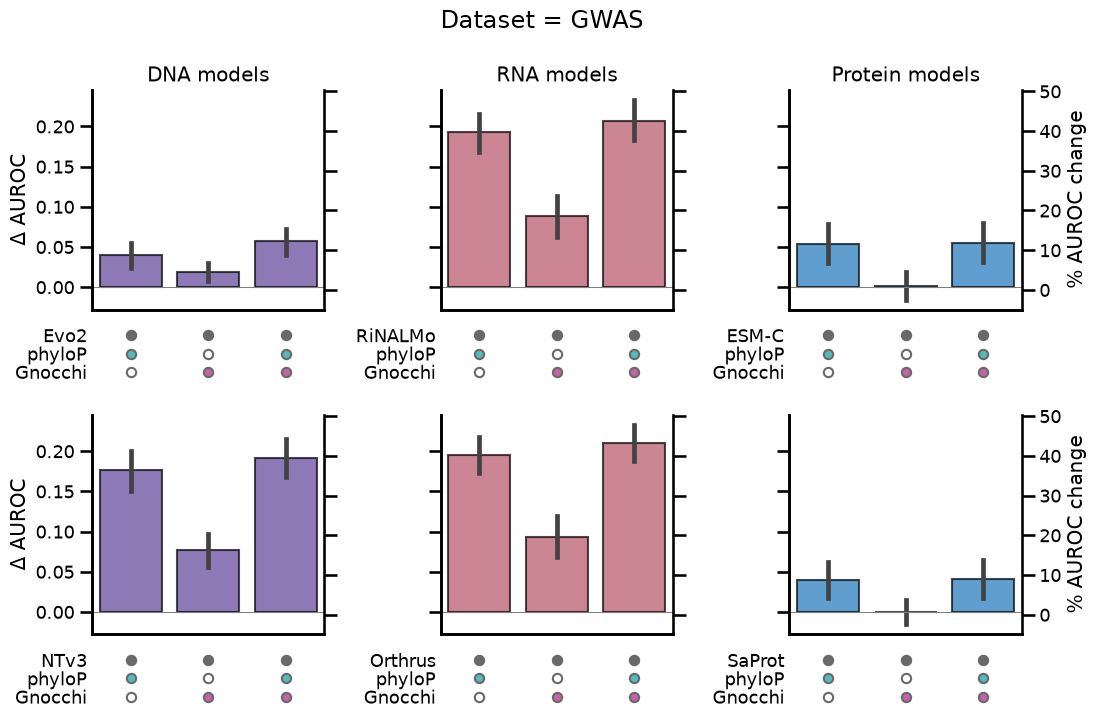

In [35]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "GWAS",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_complementarity_gwas.pdf")


/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


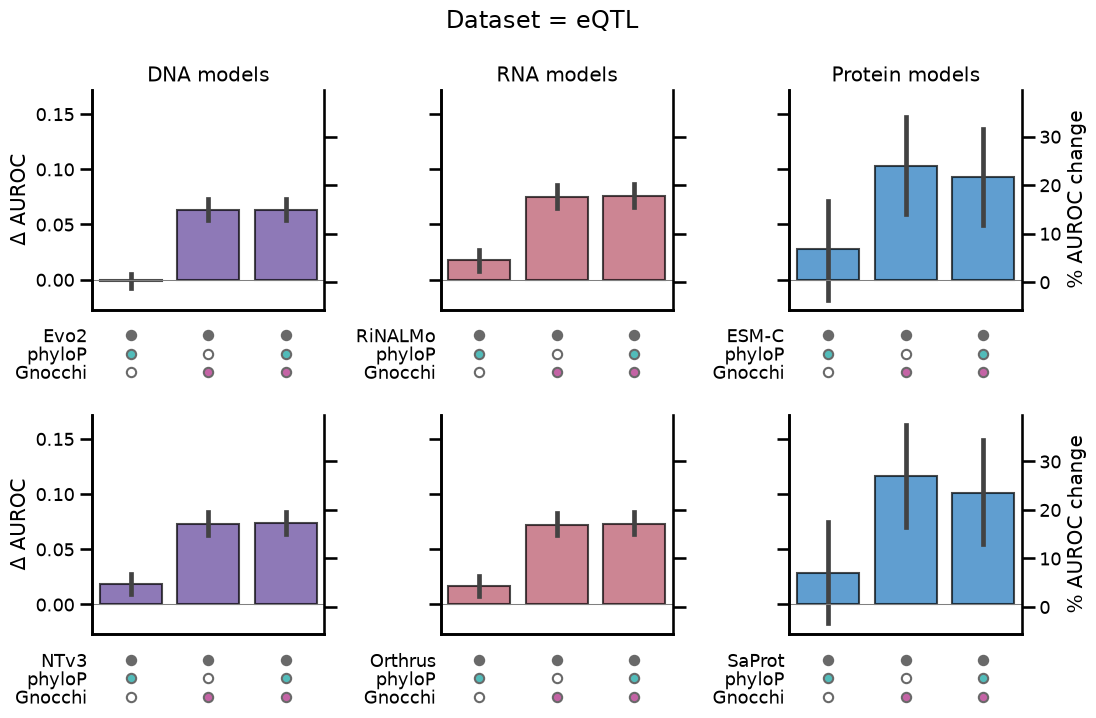

In [36]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "eQTL",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_complementarity_eqtl.pdf")

/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


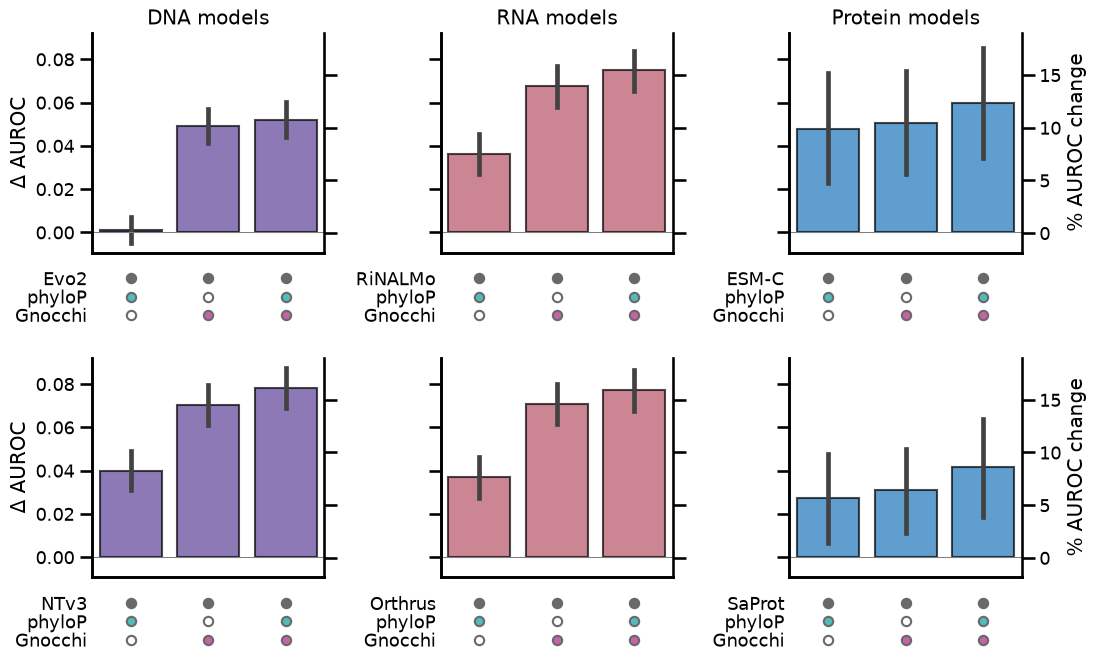

In [37]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "All",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        show_title=False,
        sharey=True,
    )

    save_fig("fig4_complementarity_eqtl_gwas.pdf")

/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


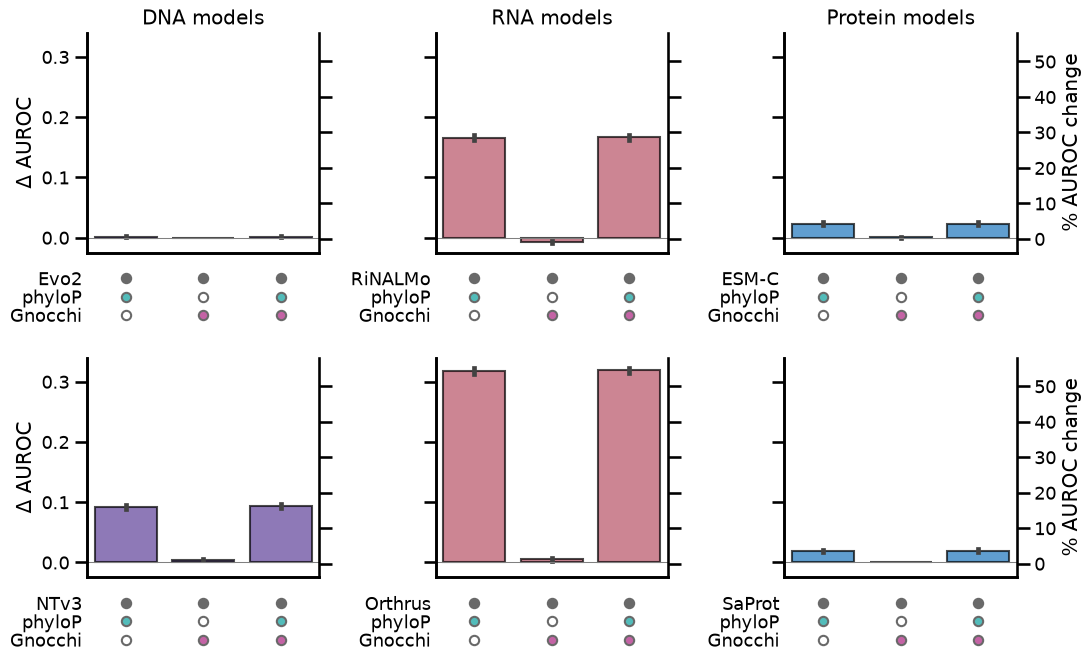

In [38]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        combined_diffs,
        "ClinVar",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        show_title=False,
        sharey=True,
    )

    save_fig("app_fig_complementarity_clinvar.pdf")

### Summary per approach

In [39]:
(
    combined_diffs.filter(
        pl.col("dataset").is_in(("eQTL", "GWAS")),
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .sort("modality")
)

modality,compare,auroc,auroc_pct
str,str,f64,f64
"""DNA""","""nt_650_gnocchi""",0.074843,14.627986
"""DNA""","""evo_gnocchi""",0.040884,7.581721
"""Protein""","""esmc_gnocchi""",0.052162,10.868705
"""Protein""","""saprot_gnocchi""",0.058309,12.627986
"""RNA""","""orthrus_gnocchi""",0.082468,16.340127
"""RNA""","""rinalmo_gnocchi""",0.081774,16.289191


In [40]:
(
    combined_diffs.filter(
        pl.col("dataset").is_in(("eQTL", "GWAS")),
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .select("auroc_pct")
    .mean()
)

auroc_pct
f64
13.055953


### Summary per approach per dataset

In [41]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(
        pl.col("compare").str.ends_with("_gnocchi"),
        pl.col("dataset") == "GWAS",
    )
    .sort("modality")
)

modality,compare,dataset,auroc,auroc_pct
str,str,str,f64,f64
"""DNA""","""nt_650_gnocchi""","""GWAS""",0.076805,14.852062
"""DNA""","""evo_gnocchi""","""GWAS""",0.018636,2.840524
"""Protein""","""saprot_gnocchi""","""GWAS""",0.00018,0.036546
"""Protein""","""esmc_gnocchi""","""GWAS""",0.001621,0.273045
"""RNA""","""rinalmo_gnocchi""","""GWAS""",0.088776,17.749163
"""RNA""","""orthrus_gnocchi""","""GWAS""",0.092645,18.517091


In [42]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(
        pl.col("compare").str.ends_with("_gnocchi"),
        pl.col("dataset") == "GWAS",
    )
    .get_column("auroc_pct")
    .mean()
)

9.044738669443193

In [43]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .group_by("dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
)

dataset,auroc,auroc_pct
str,f64,f64
"""ClinVar""",0.000593,0.101784
"""eQTL""",0.083703,17.067167
"""GWAS""",0.046444,9.044739
"""All""",0.056511,11.188618


In [44]:
(
    combined_diffs.filter(
        pl.col("ref") != "NTv3 (100M)",
    )
    .group_by("modality", "compare", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("compare").str.ends_with("_gnocchi"))
    .group_by("modality", "dataset")
    .agg(
        pl.col("auroc").mean(),
        pl.col("auroc_pct").mean(),
    )
    .filter(pl.col("dataset") != "All")
    .sort("modality", "dataset")
)

modality,dataset,auroc,auroc_pct
str,str,f64,f64
"""DNA""","""ClinVar""",0.002157,0.254002
"""DNA""","""GWAS""",0.047721,8.846293
"""DNA""","""eQTL""",0.068006,13.363414
"""Protein""","""ClinVar""",0.000297,0.03186
"""Protein""","""GWAS""",0.0009,0.154796
"""Protein""","""eQTL""",0.109571,23.341895
"""RNA""","""ClinVar""",-0.000676,0.019489
"""RNA""","""GWAS""",0.09071,18.133127
"""RNA""","""eQTL""",0.073532,14.496191


### Missense-only feature comparisons

In [47]:
ms_bootstrap_diffs

auroc,auroc_pct,auprc,auprc_pct,ref,compare,dataset
f64,f64,f64,f64,str,str,str
0.036193,5.636989,0.011261,10.993076,"""Evo2""","""evo_phylop""","""GWAS"""
0.018487,2.938183,0.000816,0.838403,"""Evo2""","""evo_phylop""","""GWAS"""
0.029106,4.514023,0.012419,10.422036,"""Evo2""","""evo_phylop""","""GWAS"""
0.015096,2.315049,0.000076,0.066405,"""Evo2""","""evo_phylop""","""GWAS"""
0.026716,4.049898,-0.000496,-0.402659,"""Evo2""","""evo_phylop""","""GWAS"""
0.038419,6.186526,0.009298,8.984248,"""Evo2""","""evo_phylop""","""GWAS"""
0.027552,4.341441,0.008579,8.333591,"""Evo2""","""evo_phylop""","""GWAS"""
0.022881,3.621107,0.006182,5.598792,"""Evo2""","""evo_phylop""","""GWAS"""
…,…,…,…,…,…,…


/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


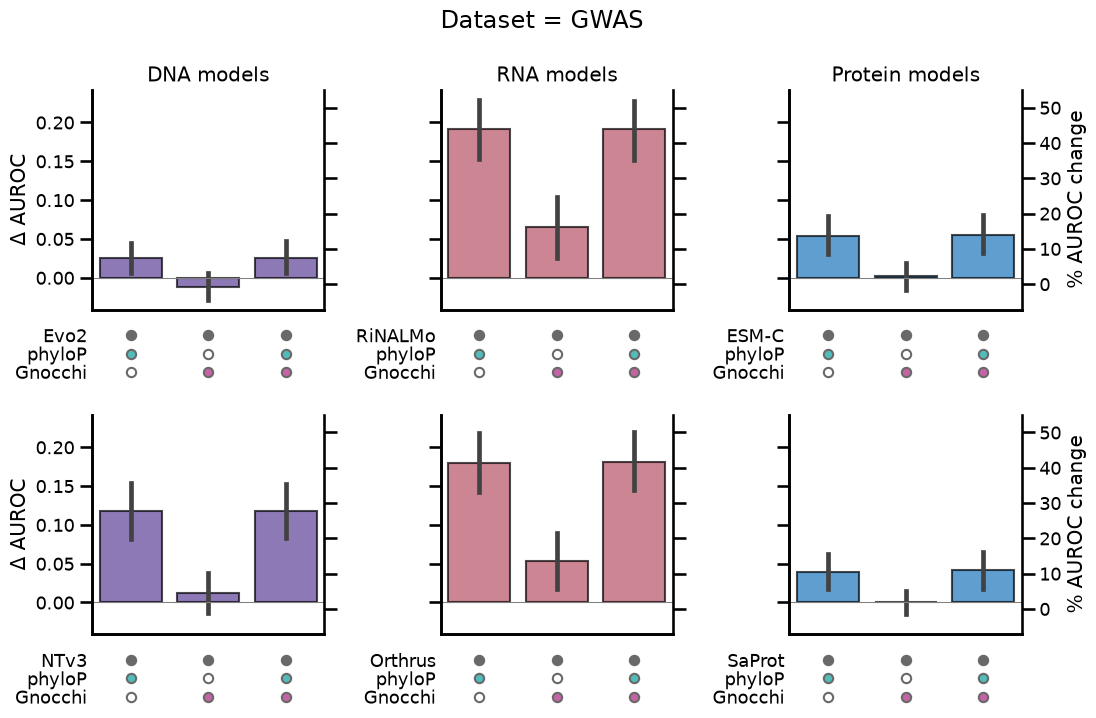

In [56]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "GWAS",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_missense_complementarity_gwas.pdf")


/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


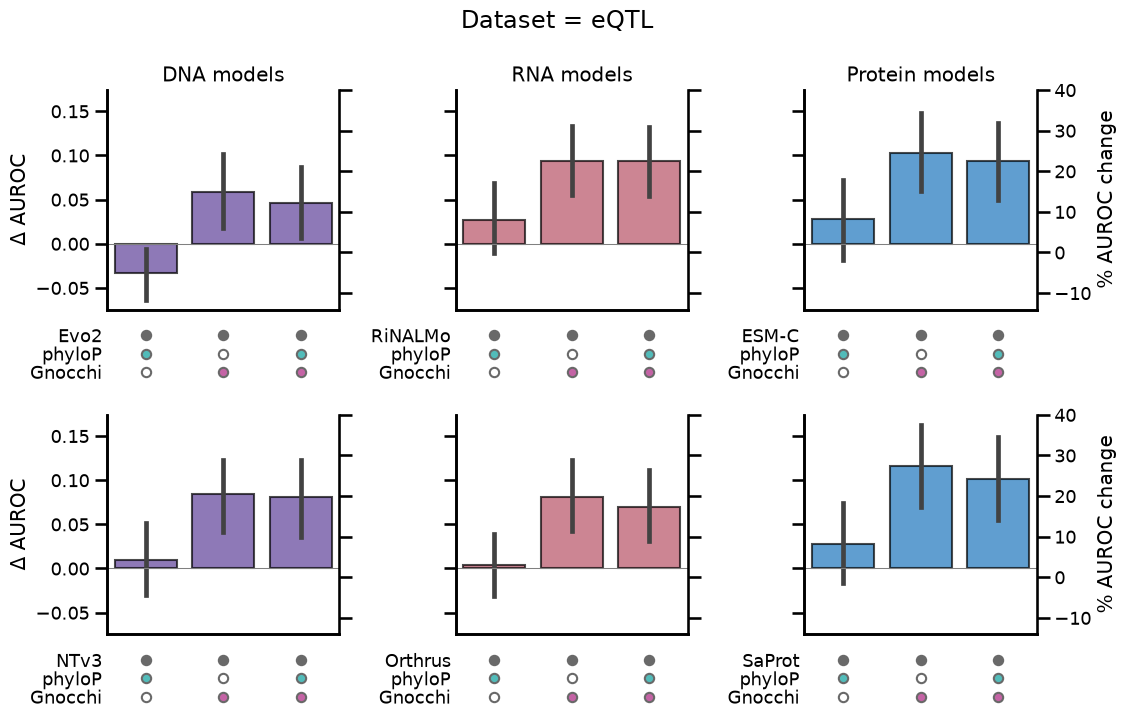

In [55]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "eQTL",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
        sharey=True,
    )
    save_fig("app_fig_missense_complementarity_eqtl.pdf")


/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


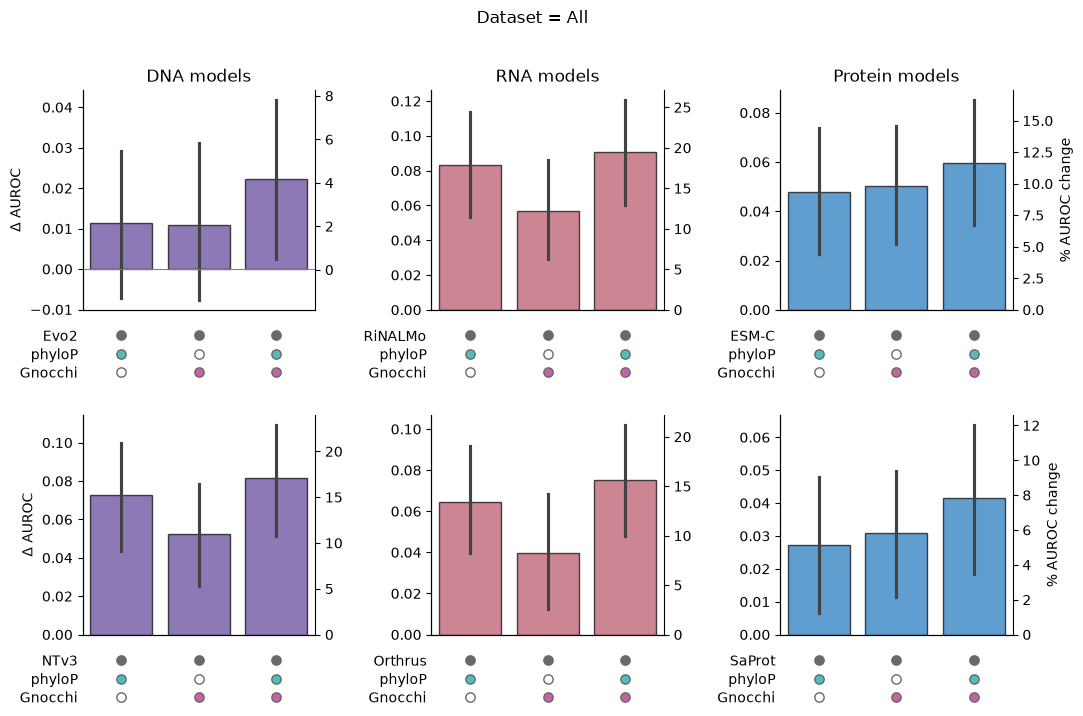

In [51]:
diffs_upset_plot_by_modality(
    ms_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
)

/tmp/ipykernel_1480375/4033182489.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


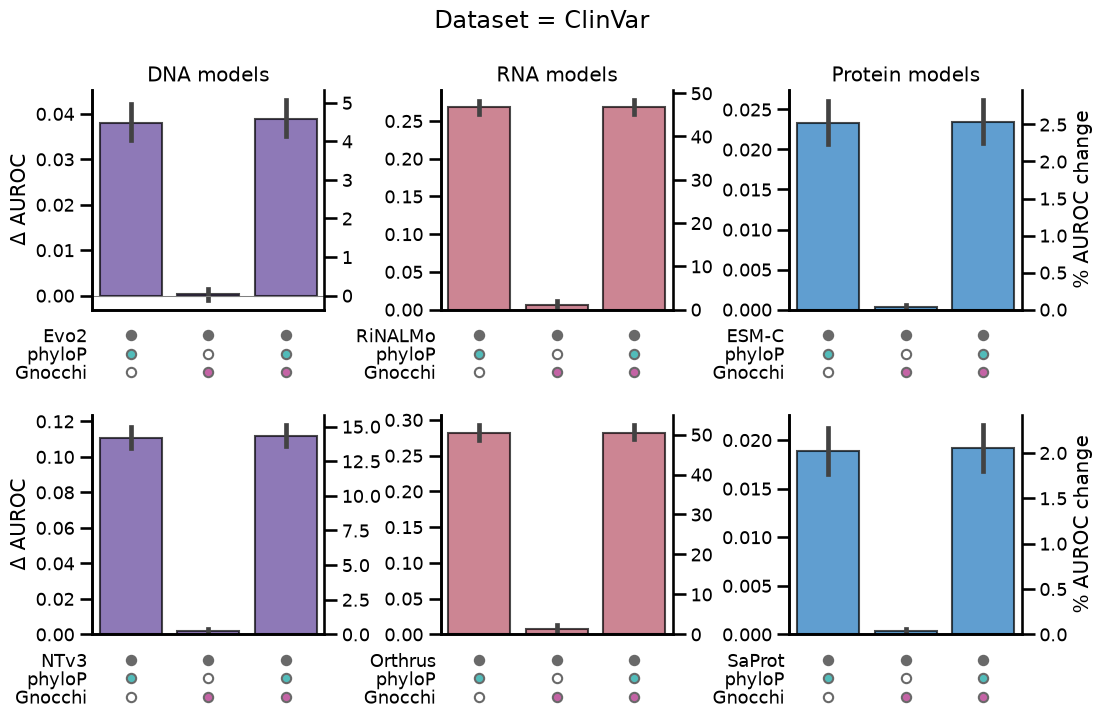

In [ ]:
with sns.plotting_context("talk", font_scale=0.8):
    diffs_upset_plot_by_modality(
        ms_bootstrap_diffs,
        "ClinVar",
        want_refs=["Evo2", "NTv3", "RiNALMo", "Orthrus", "ESM-C", "SaProt"],
    )
    save_fig("app_fig_missense_complementarity_clinvar.pdf")


### Genome-wide feature comparisons

/tmp/ipykernel_3771418/1568469681.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


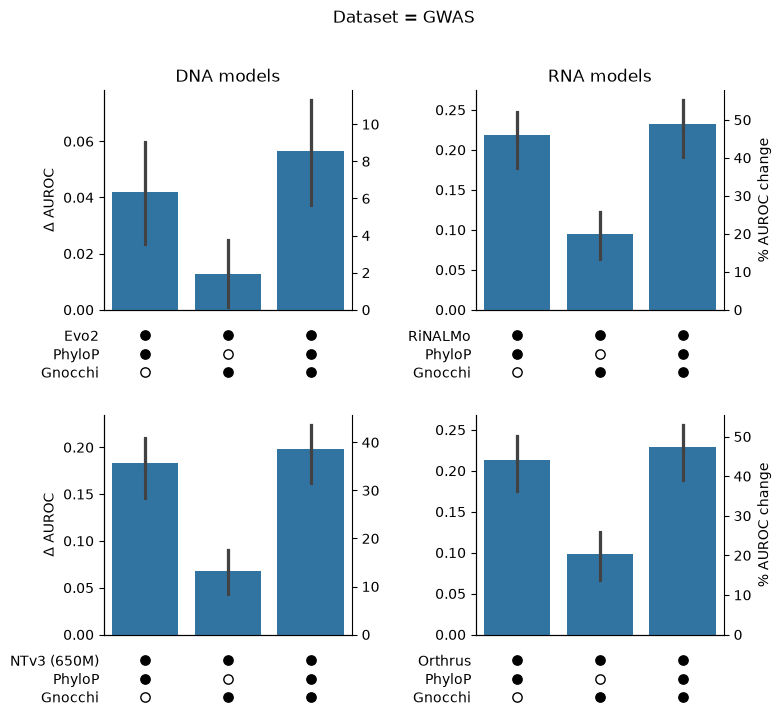

In [152]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "GWAS",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_3771418/1568469681.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


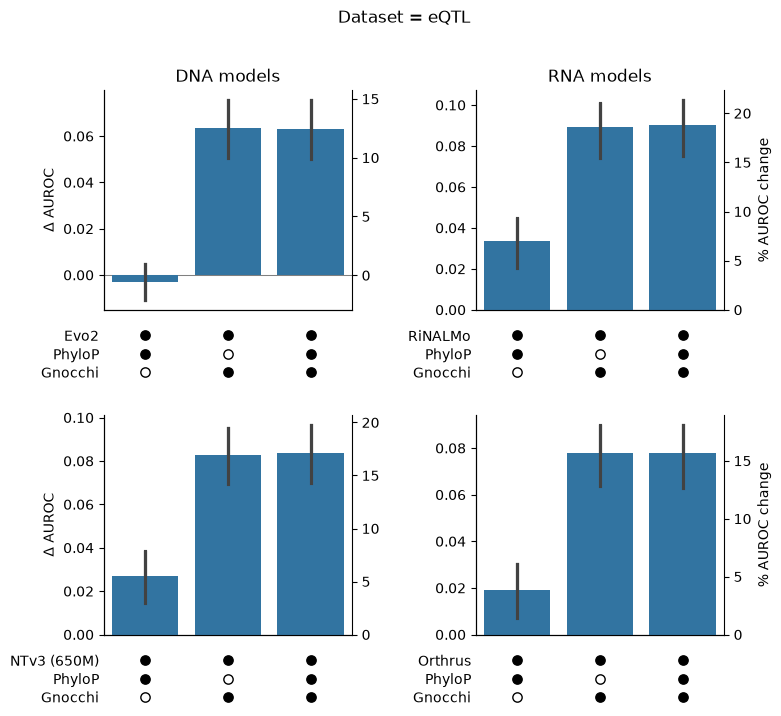

In [153]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "eQTL",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_3771418/1568469681.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


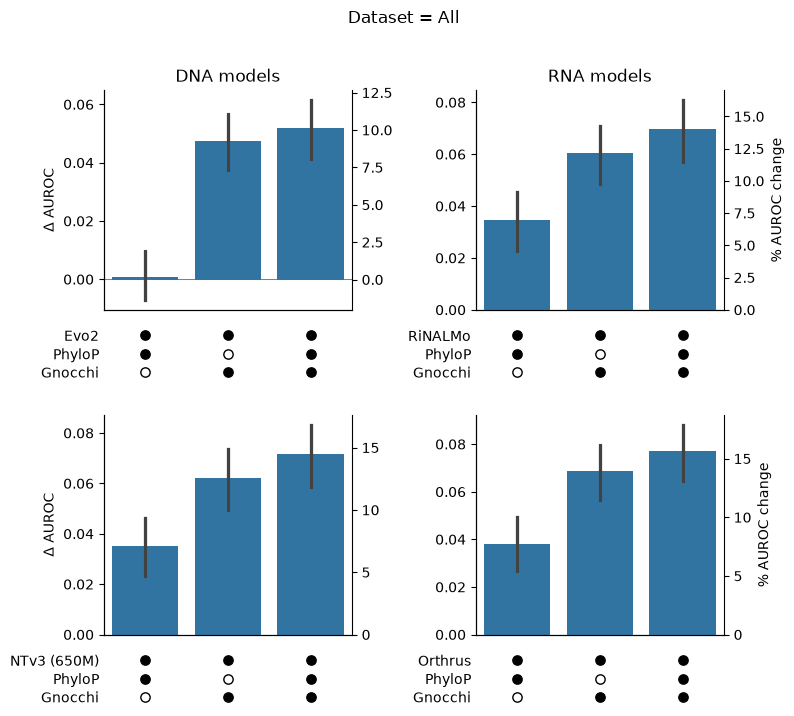

In [154]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "All",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)

/tmp/ipykernel_3771418/1568469681.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


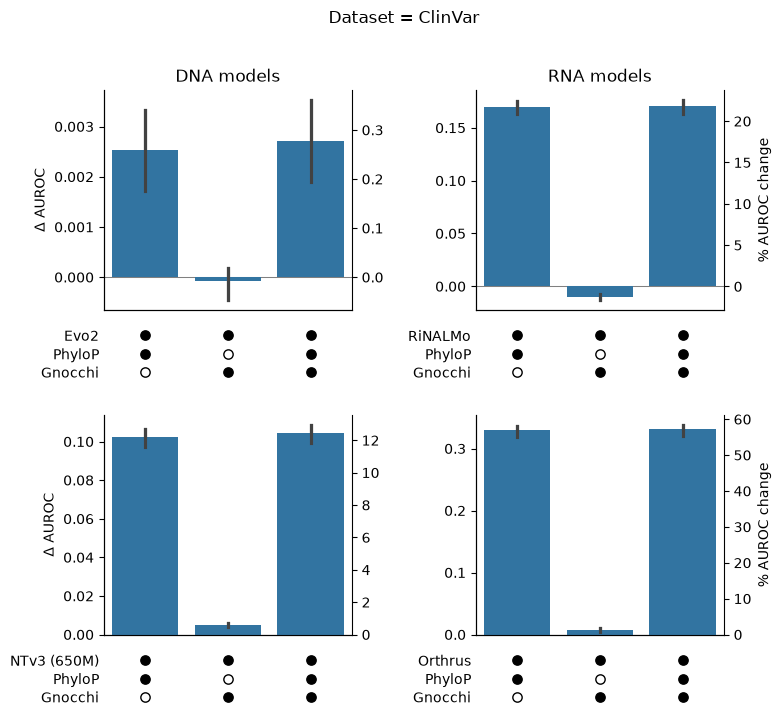

In [155]:
diffs_upset_plot_by_modality(
    gw_bootstrap_diffs,
    "ClinVar",
    want_refs=["Evo2", "NTv3 (650M)", "RiNALMo", "Orthrus"],
)